# Training a YOLO detector Using Linux


## 1. Prepare the dataset

In this example we will use the ./triggerfish_detection/dataset_10102.

We need to first divide the whole dataset up into training, validation, and testing sets. We also need to create a data.yaml file which will provide the folder paths for all the images.

In [21]:
# Remove the reload and just import once
import os
from dataset_splitter import create_dataset_split

SOURCE_IMAGE_DIR = './triggerfish_detection/dataset_10102/images'
SOURCE_LABEL_DIR = './triggerfish_detection/dataset_10102/labels'
OUTPUT_DIR = './triggerfish_detection/dataset_v5/'
TRAIN_LIST_FILE = './triggerfish_detection/dataset_v5/train.txt'
TRAINING_SPLIT = 0.8
VALIDATION_SPLIT = 0.1

# Create the split using the image list from file
split_info = create_dataset_split(
    source_image_dir=SOURCE_IMAGE_DIR,
    source_label_dir=SOURCE_LABEL_DIR,
    output_dir=OUTPUT_DIR,
    train_list_file=TRAIN_LIST_FILE,
    train_split=TRAINING_SPLIT,
    val_split=VALIDATION_SPLIT,
    random_state=42
)


=== Starting Dataset Split Process ===
Source image directory: ./triggerfish_detection/dataset_10102/images
Output directory not found at ./triggerfish_detection/dataset_v5/. Creating it...
Created output directory structure at ./triggerfish_detection/dataset_v5/

Scanning source directory for images...
Total files found in source directory: 10102
File extensions found: {'.jpg'}

Detailed count:
- Total files in directory: 10102
- Image files found: 10102
- First 5 image files:
  1. image_4862.jpg
  2. image_5411.jpg
  3. image_6319.jpg
  4. image_7502.jpg
  5. image_7871.jpg
Train list file not found at ./triggerfish_detection/dataset_v5/train.txt. Creating new one...
Created train list file with 10102 images
Total images to process: 10102

Dataset split complete:
Training images: 8081
Validation images: 1010
Test images: 1011

Created data.yaml at: ./triggerfish_detection/dataset_v5/data.yaml
Content:
path: ./triggerfish_detection/dataset_v5/  # dataset root dir
train: images/train 

## 2. Train the model

In [2]:
# Check your GPU availability
import torch

# Check CUDA availability
print(f"CUDA available: {torch.cuda.is_available()}")

# If CUDA is available, show GPU info
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU: {torch.cuda.current_device()}")

CUDA available: True
GPU Device: Quadro RTX 4000
Number of GPUs: 1
Current GPU: 0


<b>Note:</b> If you get an error in the next step about the data.yaml file, it is probably because the path is not correct because it didn't include the absolute path. I fixed it by changing the path in the data.yaml file to the absolute path but I didn't test the fix.

In [15]:
# Train the model on the new dataset

import os
import torch
import wandb
from ultralytics import YOLO

# Set PyTorch memory management
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# Define optimized training parameters
YOLO_MODEL = 'yolov8l'
EPOCHS = 50
PATIENCE = 10
BATCH_SIZE = 2 # Increased from 2
IMG_SIZE = 1024
LEARNING_RATE = 0.001 # Yolo default is 0.01. This architecture is very sensitive to the learning rate.
WORKERS = 8 # This speeds up the training process by preventing training being bottlenecked by data loading.
DEVICE=0
 
# Define directories
BASE_DIR = './triggerfish_detection'
EXPERIMENT_NUM=f"v1"
EXPERIMENT_ID = f"{YOLO_MODEL}_dataset_v5_{EXPERIMENT_NUM}"

PROJECT = "triggerfish_detection_runs"
DATASET_PATH = './triggerfish_detection/dataset_v5'
OUTPUT_DIR = os.path.join(PROJECT, EXPERIMENT_ID)


# Initialize wandb
wandb.init(
    project=PROJECT,
    name=EXPERIMENT_ID,
    config={
        "architecture": YOLO_MODEL,
        "dataset": "dataset_v5",
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "img_size": IMG_SIZE,
        "learning_rate": LEARNING_RATE,
        "patience": PATIENCE,
        "device": 'gpu',
        
    }
)
 
# Initialize model
model = YOLO(YOLO_MODEL + '.pt')
model.train(
    data=DATASET_PATH+'/data.yaml',
    epochs=EPOCHS,
    patience=PATIENCE,
    batch=BATCH_SIZE,
    imgsz=IMG_SIZE,
    lr0=LEARNING_RATE,
    device=DEVICE,
    save=True,
    project='./triggerfish_detection/detection_training_runs',  # Base directory
    name=EXPERIMENT_ID,                                        # Experiment subfold
    workers=WORKERS,
    max_det=50,
    amp=True,           # Enable mixed precision training
    cache='disk',         # Cache images in RAM
    optimizer='AdamW'   # Memory efficient optimizer
)

wandb.finish()

print(f"\nTraining completed. Model saved in: {OUTPUT_DIR}")

Ultralytics 8.3.73 🚀 Python-3.10.16 torch-2.6.0+cu118 CUDA:0 (Quadro RTX 4000, 7780MiB)
engine/trainer: task=detect, mode=train, model=yolov8l.pt, data=./triggerfish_detection/dataset_v5/data.yaml, epochs=50, time=None, patience=10, batch=2, imgsz=1024, save=True, save_period=-1, cache=disk, device=0, workers=8, project=./triggerfish_detection/detection_training_runs, name=yolov8l_dataset_v5_v1, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=50, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, 

train: Scanning /home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/labels/train.cache... 8081 images, 632 backgrounds, 3 corrupt: 100%|██████████| 8081/8081 [00:00<?, ?it/s]

train: WARNING ⚠️ /home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/images/train/image_0007.jpg: ignoring corrupt image/label: negative label values [-0.001852]
train: WARNING ⚠️ /home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/images/train/image_3008.jpg: ignoring corrupt image/label: negative label values [-0.211495]
train: WARNING ⚠️ /home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/images/train/image_7213.jpg: ignoring corrupt image/label: negative label values [-0.313315]



train: Caching images (66.3GB Disk): 100%|██████████| 8078/8078 [00:00<00:00, 28052.53it/s]
val: Scanning /home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/labels/val.cache... 1010 images, 85 backgrounds, 0 corrupt: 100%|██████████| 1010/1010 [00:00<?, ?it/s]
val: Caching images (8.2GB Disk): 100%|██████████| 1010/1010 [00:00<00:00, 20396.48it/s]


Plotting labels to triggerfish_detection/detection_training_runs/yolov8l_dataset_v5_v1/labels.jpg... 
optimizer: AdamW(lr=0.001, momentum=0.937) with parameter groups 97 weight(decay=0.0), 104 weight(decay=0.0005), 103 bias(decay=0.0)
Image sizes 1024 train, 1024 val
Using 8 dataloader workers
Logging results to triggerfish_detection/detection_training_runs/yolov8l_dataset_v5_v1
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all       1010       1979      0.942      0.904      0.957      0.596
EarlyStopping: Training stopped early as no improvement observed in last 10 epochs. Best results observed at epoch 34, best model saved as best.pt.
To update EarlyStopping(patience=10) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



44 epochs completed in 10.494 hours.
Optimizer stripped from triggerfish_detection/detection_training_runs/yolov8l_dataset_v5_v1/weights/last.pt, 87.7MB
Optimizer stripped from triggerfish_detection/detection_training_runs/yolov8l_dataset_v5_v1/weights/best.pt, 87.7MB

Validating triggerfish_detection/detection_training_runs/yolov8l_dataset_v5_v1/weights/best.pt...
Ultralytics 8.3.73 🚀 Python-3.10.16 torch-2.6.0+cu118 CUDA:0 (Quadro RTX 4000, 7780MiB)
Model summary (fused): 268 layers, 43,607,379 parameters, 0 gradients, 164.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 253/253 [00:22<00:00, 11.09it/s]


                   all       1010       1979      0.929      0.908      0.955      0.599
Speed: 0.3ms preprocess, 19.3ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to triggerfish_detection/detection_training_runs/yolov8l_dataset_v5_v1



Training completed. Model saved in: triggerfish_detection_runs/yolov8l_dataset_v5_v1


the model only needed to go to epoch 44 before it stopped improving.

## 3. Evaluate the model



### 3.1 Evaluate the model on the test set

<b>Note:</b> When running your validation on your test set, you don't need to set the confidence threshold. YOLO will use the default confidence threshold for validation. To check what the default confidence threshold is, you can use the following code:

In [85]:
from ultralytics.cfg import get_cfg
default_args = get_cfg()
print(f"Default confidence threshold for validation: {default_args.conf}")

Default confidence threshold for validation: None


In [3]:
# Empty the cache if you run into memory issues
import torch
import gc
import os

# Clear CUDA cache
if torch.cuda.is_available():
    # Empty cache
    torch.cuda.empty_cache()
    
    # Reset peak memory stats
    torch.cuda.reset_peak_memory_stats()
    
    # Clear current device
    device = torch.device('cuda:0')
    torch.cuda.set_device(device)
    
    # Force garbage collection
    gc.collect()
    
    # Optional: Set memory allocator settings
    os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:512'

# Completely remove any existing model
model = None
gc.collect()

0

In [7]:
from ultralytics import YOLO
import os
import json
from pathlib import Path
import yaml
import cv2
from PIL import Image
import numpy as np
import torch
import gc

class ModelValidator:
    def __init__(self, experiment_id, batch_size=2, img_size=1024, device=0):
        # Initialize parameters
        self.experiment_id = experiment_id
        self.batch_size = batch_size
        self.img_size = img_size
        self.device = device
        
        # Set up directories
        self.base_dir = './triggerfish_detection'
        self.project = "triggerfish_detection_runs"
        self.dataset_path = './triggerfish_detection/dataset_v5'
        self.output_dir = os.path.join(self.project, self.experiment_id)
        self.model_path = f'./triggerfish_detection/detection_training_runs/{self.experiment_id}/weights/best.pt'
        self.test_results_dir = f'./triggerfish_detection/detection_training_runs/{self.experiment_id}/test_set_validation'
        self.test_images_path = '/home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/images/test'
        
        # Create results directory
        os.makedirs(self.test_results_dir, exist_ok=True)
        
        # Initialize model and results
        self.model = None
        self.val_results = None
        self.metrics = None
        self.current_results_dir = None
        
        # Set memory management
        os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
        self._clear_memory()

    def _clear_memory(self):
        """Clear GPU memory and garbage collection"""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def load_model(self):
        """Load and prepare the YOLO model"""
        self.model = YOLO(self.model_path)
        self.model.to(self.device)
        self.model.model.eval()
        return self.model

    def _find_results_directory(self):
        """Find the most recent results directory"""
        results_dirs = sorted(Path(self.test_results_dir).glob('results*'))
        if not results_dirs:
            raise RuntimeError("No results directory found!")
        
        # Get the highest numbered results directory
        latest_num = max(int(d.name.replace('results', '') or 0) for d in results_dirs)
        self.current_results_dir = Path(self.test_results_dir) / f'results{latest_num}'
        print(f"\nUsing results directory: {self.current_results_dir}")
        return self.current_results_dir

    def validate_test_set(self):
        """Run validation on the test set"""
        try:
            print("Running validation...")
            # Find existing results directories to determine next number
            existing_dirs = list(Path(self.test_results_dir).glob('results*'))
            next_num = max((int(d.name.replace('results', '') or 0) for d in existing_dirs), default=-1) + 1
            results_name = f'results{next_num}'
            
            self.val_results = self.model.val(
                data=self.dataset_path+'/data.yaml',
                split='test',
                project=self.test_results_dir,
                name=results_name,  # Explicitly set the results directory name
                imgsz=self.img_size,
                batch=self.batch_size,
                device=self.device,
                verbose=True,
                save=True,
                save_txt=True,
                save_conf=True,
                save_json=True,
                plots=True,
                workers=1
            )
            
            self._calculate_metrics()
            self._find_results_directory()
            return self.val_results
                
        except Exception as e:
            print(f"Validation error: {e}")
            self._clear_memory()
            raise

    def _calculate_metrics(self):
        """Calculate and store metrics from validation results"""
        if self.val_results is None:
            print("Warning: No validation results available for metrics calculation")
            return
            
        self.metrics = {
            'mAP50': float(self.val_results.box.map50),
            'mAP50-95': float(self.val_results.box.map),
            'Precision': float(self.val_results.box.p),
            'Recall': float(self.val_results.box.r),
            'F1-Score': 2 * (float(self.val_results.box.p) * float(self.val_results.box.r)) / 
                         (float(self.val_results.box.p) + float(self.val_results.box.r))
        }

    def create_prediction_images(self):
        """Create and save prediction images with ground truth boxes"""
        try:
            # Use the same results directory from validation
            if self.current_results_dir is None:
                self._find_results_directory()
                
            save_dir = self.current_results_dir / 'predictions'
            save_dir.mkdir(exist_ok=True)
            
            # Save metrics if available
            if self.metrics is not None:
                metrics_path = self.current_results_dir / 'metrics.json'
                with open(metrics_path, 'w') as f:
                    json.dump(self.metrics, f, indent=4)

            # Define colors
            pred_color = (0, 255, 0)  # Green
            gt_color = (0, 0, 255)    # Red

            # Run predictions
            with torch.no_grad():
                pred_results = self.model.predict(
                    source=self.test_images_path,
                    save=False,
                    conf=0.25,
                    iou=0.7,
                    line_width=2,
                    show_boxes=True,
                    show_labels=True,
                    show_conf=True,
                    device=self.device
                )

            count = self._process_predictions(pred_results, save_dir, gt_color)
            self._print_results(save_dir, count)

        except Exception as e:
            print(f"Prediction error: {e}")
            self._clear_memory()
            raise

    def _process_predictions(self, pred_results, save_dir, gt_color):
        """Process and save prediction images"""
        print(f"\nProcessing and saving images to: {save_dir}")
        count = 0

        for r in pred_results:
            img_name = Path(r.path).stem
            label_path = Path(self.test_images_path).parent.parent / 'labels' / 'test' / f"{img_name}.txt"
            plotted_img = r.plot()

            if label_path.exists():
                plotted_img = self._add_ground_truth(plotted_img, label_path, gt_color)

            if isinstance(plotted_img, np.ndarray):
                img = Image.fromarray(plotted_img[..., ::-1])
                save_path = save_dir / f"{img_name}_pred_and_gt.jpg"
                img.save(str(save_path))
                count += 1
                if count % 10 == 0:
                    print(f"Saved {count} images...")

        return count

    def _add_ground_truth(self, plotted_img, label_path, gt_color):
        """Add ground truth boxes to the image"""
        with open(label_path) as f:
            gt_labels = f.readlines()

        img = plotted_img if isinstance(plotted_img, np.ndarray) else np.array(plotted_img)
        height, width = img.shape[:2]

        for label in gt_labels:
            class_id, x_center, y_center, w, h = map(float, label.strip().split())
            x1 = int((x_center - w/2) * width)
            y1 = int((y_center - h/2) * height)
            x2 = int((x_center + w/2) * width)
            y2 = int((y_center + h/2) * height)

            cv2.rectangle(img, (x1, y1), (x2, y2), gt_color, 2)
            cv2.putText(img, 'GT', (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, gt_color, 1)

        return img

    def _print_results(self, save_dir, count):
        """Print validation results and metrics"""
        print(f"\nSuccessfully saved {count} annotated images to:")
        print(f"{save_dir}")
        
        print("\nBox Colors:")
        print("- Green: Model Predictions")
        print("- Red: Ground Truth")

        if self.metrics:
            print("\nTest Set Metrics:")
            for metric, value in self.metrics.items():
                print(f"{metric}: {value:.3f}")

def test_image_creation():
    validator = ModelValidator(
        experiment_id="yolov8l_dataset_v5_v1",
        batch_size=2,
        img_size=1024,
        device=0
    )
    
    try:
        # Load the model
        validator.load_model()
        
        # First run validation to get metrics, labels, and plots
        print("Running validation...")
        validator.validate_test_set()
        
        # The validation results directory will now have all the necessary files
        # Now run prediction image creation in the same directory
        print("Creating prediction images...")
        validator.create_prediction_images()
    
    
    finally:
        validator._clear_memory()

if __name__ == "__main__":
    test_image_creation()

Running validation...
Running validation...
Ultralytics 8.3.73 🚀 Python-3.10.16 torch-2.6.0+cu118 CUDA:0 (Quadro RTX 4000, 7780MiB)
Model summary (fused): 268 layers, 43,607,379 parameters, 0 gradients, 164.8 GFLOPs


val: Scanning /home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/labels/test.cache... 1011 images, 79 backgrounds, 0 corrupt: 100%|██████████| 1011/1011 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 506/506 [00:57<00:00,  8.86it/s]


                   all       1011       1862      0.943      0.887      0.951      0.604
Speed: 0.4ms preprocess, 47.7ms inference, 0.0ms loss, 0.7ms postprocess per image
Saving triggerfish_detection/detection_training_runs/yolov8l_dataset_v5_v1/test_set_validation/results1/predictions.json...
Results saved to triggerfish_detection/detection_training_runs/yolov8l_dataset_v5_v1/test_set_validation/results1

Using results directory: triggerfish_detection/detection_training_runs/yolov8l_dataset_v5_v1/test_set_validation/results1
Creating prediction images...


WARNING ⚠️ inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks o

/tmp/ipykernel_5104/1888730852.py:111: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  'Precision': float(self.val_results.box.p),
/tmp/ipykernel_5104/1888730852.py:112: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  'Recall': float(self.val_results.box.r),
/tmp/ipykernel_5104/1888730852.py:113: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  'F1-Score': 2 * (float(self.val_results.box.p) * float(self.val_results.box.r)) /
/tmp/ipykernel_5104/1888730852.py:114: Deprecat

image 2/1011 /home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/images/test/Lizard_2024_02_27_AM1_Cait_Left_GX010170_frame18115.jpg: 576x1024 (no detections), 40.1ms
image 3/1011 /home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/images/test/Lizard_2024_02_27_AM1_Cait_Left_GX010170_frame18270.jpg: 576x1024 (no detections), 41.0ms
image 4/1011 /home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/images/test/Lizard_2024_02_27_AM1_Cait_Left_GX010170_frame18280.jpg: 576x1024 (no detections), 38.3ms
image 5/1011 /home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/images/test/Lizard_2024_02_27_AM1_Cait_Left_GX010170_frame18305.jpg: 576x1024 (no detections), 38.8ms
image 6/1011 /home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/images/test/Lizard_2024_02_27_AM1_Cait_Left_GX010170_frame18330.jpg: 576x1024 (no detections), 38.7ms
image 7/1011 /home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/imag

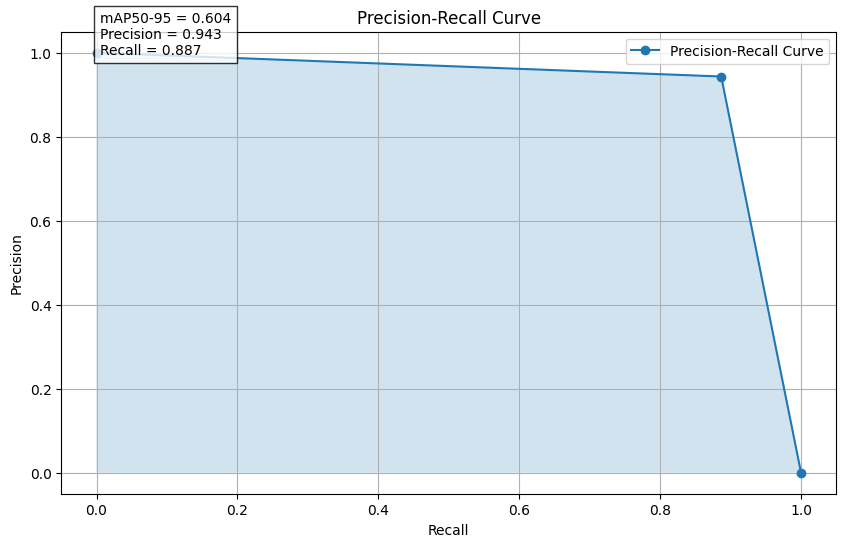

In [46]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Create precision-recall curve
plt.figure(figsize=(10, 6))

# Since we only have one point, we'll plot it and connect it to (0,1) and (1,0)
precision = float(results.box.p[0])  # Convert to float
recall = float(results.box.r[0])     # Convert to float

# Create points for the curve
x_points = [0, recall, 1]
y_points = [1, precision, 0]

plt.plot(x_points, y_points, '-o', label='Precision-Recall Curve')
plt.fill_between(x_points, y_points, alpha=0.2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.legend()

# Add metrics to plot
plt.text(0.05, 0.95, 
         f'mAP50-95 = {results.box.map:.3f}\nPrecision = {precision:.3f}\nRecall = {recall:.3f}', 
         transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.8))

plt.show()


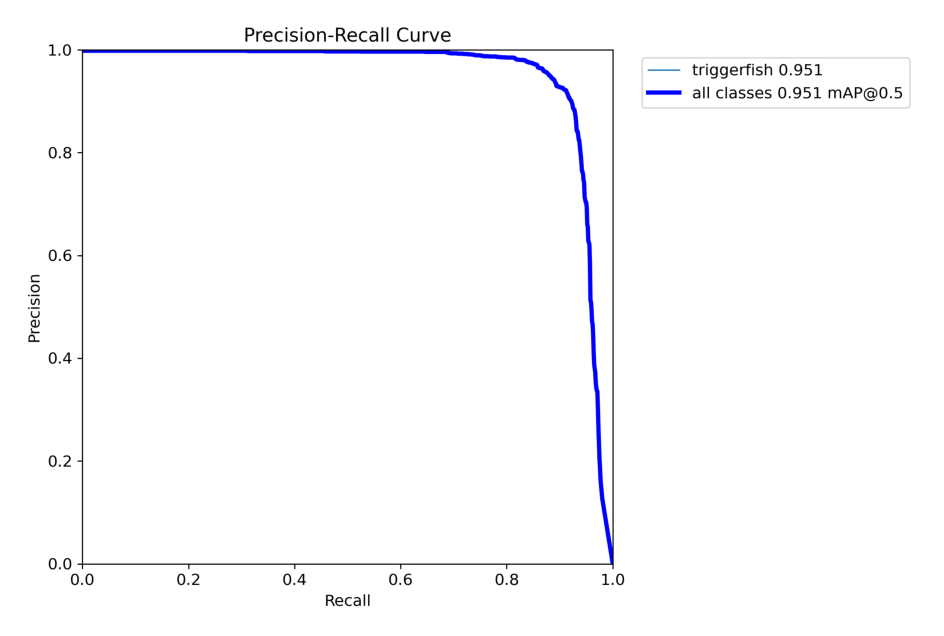

In [47]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load and display the saved PR curve
pr_curve_path = '/home/cait/projects/VideoUtilities/triggerfish_detection/detection_training_runs/yolov8l_dataset_v5_v1/test_set_validation/results/PR_curve.png'
img = mpimg.imread(pr_curve_path)

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()

### 3.2 Analyze the size distribution of the ground truth boxes

I want to look at where the model is not very good at predicting the position of the fish. Based on the dataset, I think that smaller/farther fish are harder to detect. To check this, I will check if we have more errors for smaller/farther fish.

I have dived the ground truth boxes into 4 categories based on their size:

* <b>Very small</b>: 0 to 0.0005 (0-0.05% of image area)

* <b>Small</b>: 0.0005 to 0.001 (0.05-1% of image area)

* <b>Medium</b>: 0.001 to 0.005 (1-5% of image area)

* <b>Large</b>: 0.01 to 0.1 (10-100% of image area)

I then calculate the precision, recall, and F1 score for each of these categories.




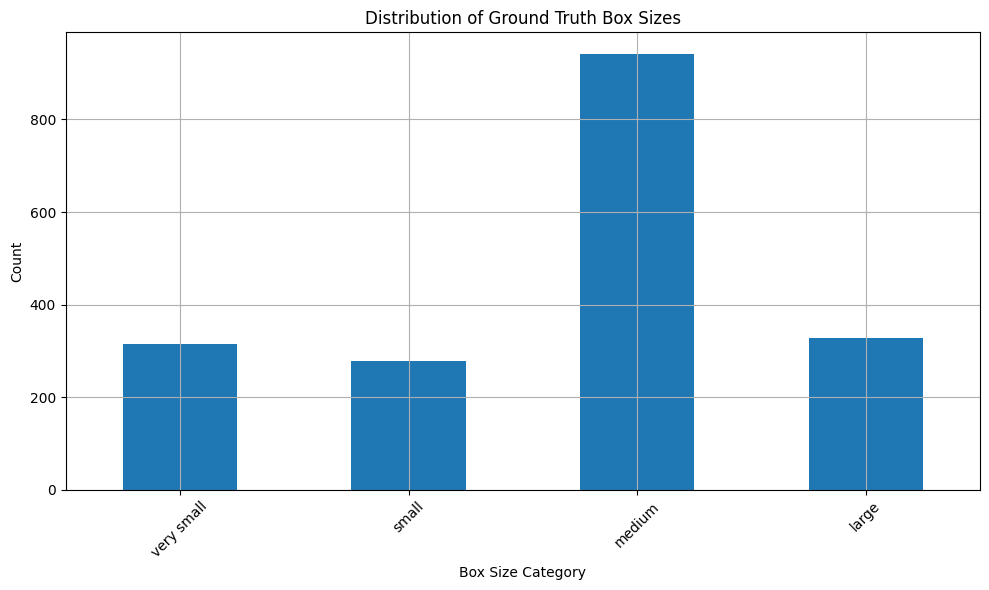


Ground Truth Box Size Statistics:
Total boxes: 1862

Size distribution:
very small: 315 boxes (16.9%)
small: 278 boxes (14.9%)
medium: 941 boxes (50.5%)
large: 328 boxes (17.6%)

Area statistics:
Min area: 0.0001
Max area: 0.0918
Mean area: 0.0033
Median area: 0.0019


In [33]:
# Decide on the size categories

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

# Get ground truth and prediction data from validation results
val_path = Path(f'./triggerfish_detection/detection_training_runs/{EXPERIMENT_ID}/test_set_validation/results/labels')
gt_path = Path(DATASET_PATH) / 'labels/test'

# Function to calculate box area
def get_box_areas(label_path):
    areas = []
    for label_file in label_path.glob('*.txt'):
        with open(label_file) as f:
            for line in f:
                # YOLO format: class x_center y_center width height
                parts = line.strip().split()
                if len(parts) == 5:  # Ensure valid format
                    width = float(parts[3])
                    height = float(parts[4])
                    area = width * height  # Normalized area
                    areas.append(area)
    return np.array(areas)

# Get areas
gt_areas = get_box_areas(gt_path)

# Define size categories (in terms of normalized area)
# In YOLO format, all bounding box coordinates and dimensions are normalized to be between 0 and 1 relative to the image size.
size_bins = [0, 0.0005, 0.001, 0.005, 0.1]  # Adjust these thresholds as needed
size_labels = ['very small', 'small', 'medium', 'large']

# Categorize boxes by size
gt_sizes = pd.cut(gt_areas, bins=size_bins, labels=size_labels)

# Count boxes in each category
size_distribution = gt_sizes.value_counts()

# Plot size distribution
plt.figure(figsize=(10, 6))
size_distribution.plot(kind='bar')
plt.title('Distribution of Ground Truth Box Sizes')
plt.xlabel('Box Size Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Print statistics
print("\nGround Truth Box Size Statistics:")
print(f"Total boxes: {len(gt_areas)}")
print("\nSize distribution:")
for size, count in size_distribution.items():
    print(f"{size}: {count} boxes ({count/len(gt_areas)*100:.1f}%)")

print("\nArea statistics:")
print(f"Min area: {gt_areas.min():.4f}")
print(f"Max area: {gt_areas.max():.4f}")
print(f"Mean area: {gt_areas.mean():.4f}")
print(f"Median area: {np.median(gt_areas):.4f}")

### 3.3 Analyse performance by size category

Match found: image_4628.jpg, GT size: very small, Pred size: very small, IOU: 0.783
False positive: image_4628.jpg, Pred size: very small, Best IOU: 0.000
Match found: image_2433.jpg, GT size: large, Pred size: medium, IOU: 0.827
Match found: image_3140.jpg, GT size: large, Pred size: large, IOU: 0.851
Match found: image_3140.jpg, GT size: medium, Pred size: medium, IOU: 0.852
Match found: image_4123.jpg, GT size: large, Pred size: large, IOU: 0.906
Match found: image_3693.jpg, GT size: large, Pred size: large, IOU: 0.784
Match found: image_7037.jpg, GT size: large, Pred size: large, IOU: 0.934
Match found: image_7037.jpg, GT size: large, Pred size: large, IOU: 0.874
Match found: image_7037.jpg, GT size: medium, Pred size: medium, IOU: 0.826
Match found: image_7037.jpg, GT size: large, Pred size: large, IOU: 0.751
Match found: image_7037.jpg, GT size: medium, Pred size: medium, IOU: 0.764
False positive: image_7037.jpg, Pred size: small, Best IOU: 0.468
Match found: image_2675.jpg, GT 

<Figure size 1200x600 with 0 Axes>

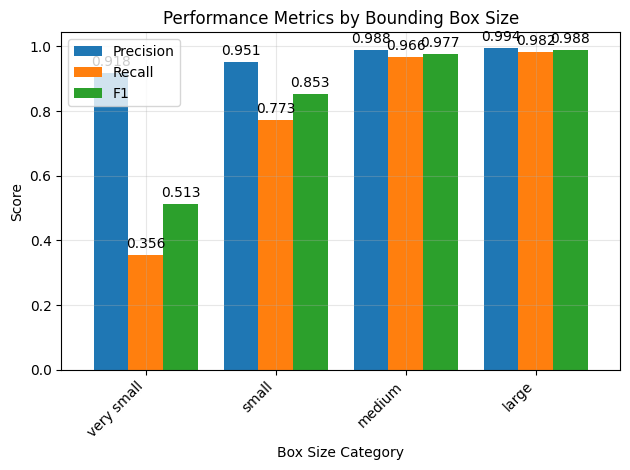

In [55]:
# Analyze performance by size category

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from collections import defaultdict
import csv
from datetime import datetime

# Define size categories
size_bins = [0, 0.0005, 0.001, 0.005, 0.1]  # Adjust these thresholds as needed
size_labels = ['very small', 'small', 'medium', 'large']

def analyze_performance_by_size():
    # Get paths
    test_images_path = Path(DATASET_PATH) / 'images/test'
    gt_path = Path(DATASET_PATH) / 'labels/test'
    
    # Create results directory if it doesn't exist
    results_dir = Path('./triggerfish_detection/detection_training_runs/yolov8l_dataset_v5_v1/test_set_validation/size_analysis')
    results_dir.mkdir(parents=True, exist_ok=True)
    
    # Create CSV file for detailed results
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    csv_path = results_dir / f'detection_results_{timestamp}.csv'
    
    # Initialize debug counters
    debug_counters = defaultdict(lambda: {'gt_total': 0, 'tp': 0, 'fp': 0, 'fn': 0})
    
    # Prepare CSV headers
    csv_headers = ['image_name', 'size_category', 'prediction_type', 'confidence', 
                  'area', 'gt_box', 'pred_box', 'iou']
    
    with open(csv_path, 'w', newline='') as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=csv_headers)
        writer.writeheader()
        
        # Process each test image
        for img_file in test_images_path.glob('*.jpg'):
            # Get corresponding label file
            label_file = gt_path / f"{img_file.stem}.txt"
            
            # Get predictions for this image
            pred_results = model.predict(str(img_file), conf=0.5, verbose=False)[0]
            img_height, img_width = pred_results.orig_shape
            
            # Get ground truth boxes
            gt_boxes = []
            if label_file.exists():
                with open(label_file) as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) == 5:  # class x_center y_center width height
                            _, x, y, w, h = map(float, parts)
                            area = w * h
                            size_category = pd.cut([area], bins=size_bins, labels=size_labels)[0]
                            if size_category in size_labels:
                                debug_counters[size_category]['gt_total'] += 1
                                debug_counters[size_category]['fn'] += 1  # Will be decremented for matches
                                gt_boxes.append({
                                    'box': [x, y, w, h], 
                                    'size': size_category, 
                                    'matched': False,
                                    'area': area
                                })
            
            # Process predictions
            for box in pred_results.boxes:
                xyxy = box.xyxy[0].cpu().numpy()  # Get box in xyxy format
                conf = float(box.conf[0].cpu().numpy())  # Get confidence
                
                # Convert to normalized coordinates
                x1, y1, x2, y2 = xyxy / np.array([img_width, img_height, img_width, img_height])
                w = x2 - x1
                h = y2 - y1
                area = w * h
                
                size_category = pd.cut([area], bins=size_bins, labels=size_labels)[0]
                if size_category in size_labels:
                    # Find best matching ground truth box
                    best_iou = 0
                    best_gt_idx = -1
                    best_gt_size = None
                    
                    for idx, gt in enumerate(gt_boxes):
                        if not gt['matched']:  # Only consider unmatched ground truth boxes
                            iou = calculate_iou([x1, y1, x2, y2], gt['box'])
                            if iou > best_iou:
                                best_iou = iou
                                best_gt_idx = idx
                                best_gt_size = gt['size']
                    
                    # Record results
                    result_row = {
                        'image_name': img_file.name,
                        'size_category': size_category,
                        'confidence': conf,
                        'area': area,
                        'pred_box': f"[{x1:.4f}, {y1:.4f}, {x2:.4f}, {y2:.4f}]"
                    }
                    
                    if best_iou > 0.5:  # IOU threshold
                        # Update debug counters
                        debug_counters[best_gt_size]['tp'] += 1
                        debug_counters[best_gt_size]['fn'] -= 1
                        gt_boxes[best_gt_idx]['matched'] = True
                        
                        result_row.update({
                            'prediction_type': 'true_positive',
                            'gt_box': f"[{gt_boxes[best_gt_idx]['box'][0]:.4f}, {gt_boxes[best_gt_idx]['box'][1]:.4f}, "
                                    f"{gt_boxes[best_gt_idx]['box'][2]:.4f}, {gt_boxes[best_gt_idx]['box'][3]:.4f}]",
                            'iou': best_iou
                        })
                        print(f"Match found: {img_file.name}, GT size: {best_gt_size}, Pred size: {size_category}, IOU: {best_iou:.3f}")
                    else:
                        # Update debug counters
                        debug_counters[size_category]['fp'] += 1
                        
                        result_row.update({
                            'prediction_type': 'false_positive',
                            'gt_box': '',
                            'iou': best_iou
                        })
                        print(f"False positive: {img_file.name}, Pred size: {size_category}, Best IOU: {best_iou:.3f}")
                    
                    writer.writerow(result_row)
            
            # Record false negatives
            for gt in gt_boxes:
                if not gt['matched']:
                    writer.writerow({
                        'image_name': img_file.name,
                        'size_category': gt['size'],
                        'prediction_type': 'false_negative',
                        'confidence': 0.0,
                        'area': gt['area'],
                        'gt_box': f"[{gt['box'][0]:.4f}, {gt['box'][1]:.4f}, {gt['box'][2]:.4f}, {gt['box'][3]:.4f}]",
                        'pred_box': '',
                        'iou': 0.0
                    })

    # Print debug information
    print("\nDetailed Counters:")
    for size in size_labels:
        counts = debug_counters[size]
        print(f"\n{size} category:")
        print(f"Ground Truth Total: {counts['gt_total']}")
        print(f"True Positives: {counts['tp']}")
        print(f"False Positives: {counts['fp']}")
        print(f"False Negatives: {counts['fn']}")
        print(f"TP + FN = {counts['tp'] + counts['fn']} (should equal GT total)")

    # Calculate final metrics
    results = {}
    for size in size_labels:
        counts = debug_counters[size]
        total_gt = counts['gt_total']
        tp = counts['tp']
        fp = counts['fp']
        fn = counts['fn']
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        results[size] = {
            'Total Objects': total_gt,
            'Precision': precision,
            'Recall': recall,
            'F1': f1
        }
    
    # Save summary metrics
    metrics_df = pd.DataFrame(results).T
    metrics_df.to_csv(results_dir / f'summary_metrics_{timestamp}.csv')
    
    return metrics_df

def calculate_iou(box1, box2):
    """Calculate IOU between boxes (xyxy format for box1, xywh format for box2)"""
    # Convert box2 from xywh to xyxy format
    x_center, y_center, w, h = box2
    box2_xyxy = np.array([
        x_center - w/2,
        y_center - h/2,
        x_center + w/2,
        y_center + h/2
    ])
    
    # Calculate intersection
    x1 = max(box1[0], box2_xyxy[0])
    y1 = max(box1[1], box2_xyxy[1])
    x2 = min(box1[2], box2_xyxy[2])
    y2 = min(box1[3], box2_xyxy[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    
    # Calculate areas
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = w * h
    
    # Calculate IOU
    union = area1 + area2 - intersection
    return intersection / union if union > 0 else 0

# Calculate and display metrics
metrics_df = analyze_performance_by_size()
print("\nPerformance Metrics by Size:")
print(metrics_df.round(3))

# Create and display the plot
plt.figure(figsize=(12, 6))
ax = metrics_df[['Precision', 'Recall', 'F1']].plot(kind='bar', width=0.8)
plt.title('Performance Metrics by Bounding Box Size')
plt.xlabel('Box Size Category')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Display the plot
plt.show()

Ground Truth Total = Total number of actual objects we're trying to detect
True Positives = Correct detections
False Negatives = Missed detections
False Positives = Extra/incorrect detections

### 3.4 Conclusion

Here is a reminder of the meaning of the different metrics:
<b>Precision:</b> "How many of our detections are correct?"
* Precision = TP / (TP + FP)
* Of all the boxes we predicted, what percentage were actual triggerfish?

<b>Recall:</b> "How many of the actual objects did we find?"
* Recall = TP / (TP + FN)
* Of all the actual triggerfish, what percentage did we detect?

<b>F1:</b> "Balanced score between precision and recall"
* F1 = 2 (Precision Recall) / (Precision + Recall)
* Single score that balances between finding all objects (recall) and being accurate (precision)

In our data, the model is very good at detecting large fish and medium fish. For small and very small fish, the Precision remains high. So when we detect a fish, it is generally correct. But the recal is very low, so it is only finding 35% of very small fish and 77% of small fish.

I will try to retrain a model using a larger image size and an even bigger model to see if it improves the performance. The larget image size may help the model 'see' the smaller fish better.

## 4. Retrain the model with new parameters (Experiment = v2)

I am going to make two changes:

* Use a larger image size (1280)
* Reduced the number of epochs to 45 because the previous model stopped improving at epoch 44

I wanted to move up to model yolov8x, but I was running into memory issues. So I stuck with yolov8l.

In [63]:
import torch
import gc

def clear_gpu_memory():
    """Clear GPU memory by releasing PyTorch memory and running garbage collection"""
    # Clear PyTorch's CUDA memory
    torch.cuda.empty_cache()
    
    # Force garbage collection
    gc.collect()
    
    # Optional: Print memory stats to verify
    print(f"GPU Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"GPU Memory Allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    print(f"GPU Memory Reserved: {torch.cuda.memory_reserved() / 1e9:.2f} GB")

# Call this function before training
clear_gpu_memory()

GPU Memory Available: 8.16 GB
GPU Memory Allocated: 0.08 GB
GPU Memory Reserved: 6.52 GB


In [64]:
# Train the model with new parameters

import os
import torch
import wandb
from ultralytics import YOLO
from datetime import datetime
import time

# Record start time
start_time = time.time()
start_datetime = datetime.now()

print(f"Training started at: {start_datetime.strftime('%Y-%m-%d %H:%M:%S')}")


# Set PyTorch memory management
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# Define optimized training parameters for CPU
YOLO_MODEL = 'yolov8l'
EPOCHS = 45
PATIENCE = 10
BATCH_SIZE = 2 # Increased from 2
IMG_SIZE = 1280
LEARNING_RATE = 0.001 # Yolo default is 0.01. This architecture is very sensitive to the learning rate.
WORKERS = 4 # This speeds up the training process by preventing training being bottlenecked by data loading.
DEVICE=0
 
# Define directories
BASE_DIR = './triggerfish_detection'
EXPERIMENT_NUM=f"v2"
EXPERIMENT_ID = f"{YOLO_MODEL}_dataset_v5_{EXPERIMENT_NUM}"

PROJECT = "triggerfish_detection_runs"
DATASET_PATH = './triggerfish_detection/dataset_v5'
OUTPUT_DIR = os.path.join(PROJECT, EXPERIMENT_ID)


# Initialize wandb
wandb.init(
    project=PROJECT,
    name=EXPERIMENT_ID,
    config={
        "architecture": YOLO_MODEL,
        "dataset": "dataset_v5",
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "img_size": IMG_SIZE,
        "learning_rate": LEARNING_RATE,
        "patience": PATIENCE,
        "device": 'gpu',
        
    }
)
 
# Initialize model
model = YOLO(YOLO_MODEL + '.pt')
model.train(
    data=DATASET_PATH+'/data.yaml',
    epochs=EPOCHS,
    patience=PATIENCE,
    batch=BATCH_SIZE,
    imgsz=IMG_SIZE,
    lr0=LEARNING_RATE,
    device=DEVICE,
    save=True,
    project='./triggerfish_detection/detection_training_runs',  # Base directory
    name=EXPERIMENT_ID,                                        # Experiment subfold
    workers=WORKERS,
    max_det=50,
    amp=True,           # Enable mixed precision training
    cache='disk',         # Cache images in RAM
    optimizer='AdamW'   # Memory efficient optimizer
)

wandb.finish()

print(f"\nTraining completed. Model saved in: {OUTPUT_DIR}")

# Calculate and display duration
end_time = time.time()
end_datetime = datetime.now()

duration_seconds = end_time - start_time
hours = int(duration_seconds // 3600)
minutes = int((duration_seconds % 3600) // 60)
seconds = int(duration_seconds % 60)

print(f"\nTraining completed at: {end_datetime.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total training time: {hours}h {minutes}m {seconds}s")
print(f"Total training time in seconds: {duration_seconds:.2f}s")

Training started at: 2025-02-10 13:04:47
New https://pypi.org/project/ultralytics/8.3.74 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.73 🚀 Python-3.10.16 torch-2.6.0+cu118 CUDA:0 (Quadro RTX 4000, 7780MiB)
engine/trainer: task=detect, mode=train, model=yolov8l.pt, data=./triggerfish_detection/dataset_v5/data.yaml, epochs=45, time=None, patience=10, batch=2, imgsz=1280, save=True, save_period=-1, cache=disk, device=0, workers=4, project=./triggerfish_detection/detection_training_runs, name=yolov8l_dataset_v5_v22, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=50, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, vi

train: Scanning /home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/labels/train.cache... 8081 images, 632 backgrounds, 3 corrupt: 100%|██████████| 8081/8081 [00:00<?, ?it/s]

train: WARNING ⚠️ /home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/images/train/image_0007.jpg: ignoring corrupt image/label: negative label values [-0.001852]
train: WARNING ⚠️ /home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/images/train/image_3008.jpg: ignoring corrupt image/label: negative label values [-0.211495]
train: WARNING ⚠️ /home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/images/train/image_7213.jpg: ignoring corrupt image/label: negative label values [-0.313315]



train: Caching images (66.3GB Disk): 100%|██████████| 8078/8078 [00:00<00:00, 34864.88it/s]
val: Scanning /home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/labels/val.cache... 1010 images, 85 backgrounds, 0 corrupt: 100%|██████████| 1010/1010 [00:00<?, ?it/s]
val: Caching images (8.2GB Disk): 100%|██████████| 1010/1010 [00:00<00:00, 27637.85it/s]


Plotting labels to triggerfish_detection/detection_training_runs/yolov8l_dataset_v5_v22/labels.jpg... 
optimizer: AdamW(lr=0.001, momentum=0.937) with parameter groups 97 weight(decay=0.0), 104 weight(decay=0.0005), 103 bias(decay=0.0)
Image sizes 1280 train, 1280 val
Using 4 dataloader workers
Logging results to triggerfish_detection/detection_training_runs/yolov8l_dataset_v5_v22
Starting training for 45 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all       1010       1979      0.948      0.919      0.964      0.612



45 epochs completed in 17.640 hours.
Optimizer stripped from triggerfish_detection/detection_training_runs/yolov8l_dataset_v5_v22/weights/last.pt, 87.7MB
Optimizer stripped from triggerfish_detection/detection_training_runs/yolov8l_dataset_v5_v22/weights/best.pt, 87.7MB

Validating triggerfish_detection/detection_training_runs/yolov8l_dataset_v5_v22/weights/best.pt...
Ultralytics 8.3.73 🚀 Python-3.10.16 torch-2.6.0+cu118 CUDA:0 (Quadro RTX 4000, 7780MiB)
Model summary (fused): 268 layers, 43,607,379 parameters, 0 gradients, 164.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 253/253 [00:35<00:00,  7.06it/s]


                   all       1010       1979      0.949      0.919      0.964      0.612
Speed: 0.5ms preprocess, 31.5ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to triggerfish_detection/detection_training_runs/yolov8l_dataset_v5_v22



Training completed. Model saved in: triggerfish_detection_runs/yolov8l_dataset_v5_v2

Training completed at: 2025-02-11 06:44:00
Total training time: 17h 39m 13s
Total training time in seconds: 63553.32s


### 4.1 Evaluate the model

In [8]:
# Evaluate the model
# Results are saved in the test_set_validation folder
 
from ultralytics import YOLO
import os
import json
from pathlib import Path
import yaml
import cv2
from PIL import Image
import numpy as np
import torch
import gc

class ModelValidator:
    def __init__(self, experiment_id, batch_size=2, img_size=1024, device=0):
        # Initialize parameters
        self.experiment_id = experiment_id
        self.batch_size = batch_size
        self.img_size = img_size
        self.device = device
        
        # Set up directories
        self.base_dir = './triggerfish_detection'
        self.project = "triggerfish_detection_runs"
        self.dataset_path = './triggerfish_detection/dataset_v5'
        self.output_dir = os.path.join(self.project, self.experiment_id)
        self.model_path = f'./triggerfish_detection/detection_training_runs/{self.experiment_id}/weights/best.pt'
        self.test_results_dir = f'./triggerfish_detection/detection_training_runs/{self.experiment_id}/test_set_validation'
        self.test_images_path = '/home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/images/test'
        
        # Create results directory
        os.makedirs(self.test_results_dir, exist_ok=True)
        
        # Initialize model and results
        self.model = None
        self.val_results = None
        self.metrics = None
        self.current_results_dir = None
        
        # Set memory management
        os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
        self._clear_memory()

    def _clear_memory(self):
        """Clear GPU memory and garbage collection"""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def load_model(self):
        """Load and prepare the YOLO model"""
        self.model = YOLO(self.model_path)
        self.model.to(self.device)
        self.model.model.eval()
        return self.model

    def _find_results_directory(self):
        """Find the most recent results directory"""
        results_dirs = sorted(Path(self.test_results_dir).glob('results*'))
        if not results_dirs:
            raise RuntimeError("No results directory found!")
        
        # Get the highest numbered results directory
        latest_num = max(int(d.name.replace('results', '') or 0) for d in results_dirs)
        self.current_results_dir = Path(self.test_results_dir) / f'results{latest_num}'
        print(f"\nUsing results directory: {self.current_results_dir}")
        return self.current_results_dir

    def validate_test_set(self):
        """Run validation on the test set"""
        try:
            print("Running validation...")
            # Find existing results directories to determine next number
            existing_dirs = list(Path(self.test_results_dir).glob('results*'))
            next_num = max((int(d.name.replace('results', '') or 0) for d in existing_dirs), default=-1) + 1
            results_name = f'results{next_num}'
            
            self.val_results = self.model.val(
                data=self.dataset_path+'/data.yaml',
                split='test',
                project=self.test_results_dir,
                name=results_name,  # Explicitly set the results directory name
                imgsz=self.img_size,
                batch=self.batch_size,
                device=self.device,
                verbose=True,
                save=True,
                save_txt=True,
                save_conf=True,
                save_json=True,
                plots=True,
                workers=1
            )
            
            self._calculate_metrics()
            self._find_results_directory()
            return self.val_results
                
        except Exception as e:
            print(f"Validation error: {e}")
            self._clear_memory()
            raise

    def _calculate_metrics(self):
        """Calculate and store metrics from validation results"""
        if self.val_results is None:
            print("Warning: No validation results available for metrics calculation")
            return
            
        self.metrics = {
            'mAP50': float(self.val_results.box.map50),
            'mAP50-95': float(self.val_results.box.map),
            'Precision': float(self.val_results.box.p),
            'Recall': float(self.val_results.box.r),
            'F1-Score': 2 * (float(self.val_results.box.p) * float(self.val_results.box.r)) / 
                         (float(self.val_results.box.p) + float(self.val_results.box.r))
        }

    def create_prediction_images(self):
        """Create and save prediction images with ground truth boxes"""
        try:
            # Use the same results directory from validation
            if self.current_results_dir is None:
                self._find_results_directory()
                
            save_dir = self.current_results_dir / 'predictions'
            save_dir.mkdir(exist_ok=True)
            
            # Save metrics if available
            if self.metrics is not None:
                metrics_path = self.current_results_dir / 'metrics.json'
                with open(metrics_path, 'w') as f:
                    json.dump(self.metrics, f, indent=4)

            # Define colors
            pred_color = (0, 255, 0)  # Green
            gt_color = (0, 0, 255)    # Red

            # Run predictions
            with torch.no_grad():
                pred_results = self.model.predict(
                    source=self.test_images_path,
                    save=False,
                    conf=0.25,
                    iou=0.7,
                    line_width=2,
                    show_boxes=True,
                    show_labels=True,
                    show_conf=True,
                    device=self.device
                )

            count = self._process_predictions(pred_results, save_dir, gt_color)
            self._print_results(save_dir, count)

        except Exception as e:
            print(f"Prediction error: {e}")
            self._clear_memory()
            raise

    def _process_predictions(self, pred_results, save_dir, gt_color):
        """Process and save prediction images"""
        print(f"\nProcessing and saving images to: {save_dir}")
        count = 0

        for r in pred_results:
            img_name = Path(r.path).stem
            label_path = Path(self.test_images_path).parent.parent / 'labels' / 'test' / f"{img_name}.txt"
            plotted_img = r.plot()

            if label_path.exists():
                plotted_img = self._add_ground_truth(plotted_img, label_path, gt_color)

            if isinstance(plotted_img, np.ndarray):
                img = Image.fromarray(plotted_img[..., ::-1])
                save_path = save_dir / f"{img_name}_pred_and_gt.jpg"
                img.save(str(save_path))
                count += 1
                if count % 10 == 0:
                    print(f"Saved {count} images...")

        return count

    def _add_ground_truth(self, plotted_img, label_path, gt_color):
        """Add ground truth boxes to the image"""
        with open(label_path) as f:
            gt_labels = f.readlines()

        img = plotted_img if isinstance(plotted_img, np.ndarray) else np.array(plotted_img)
        height, width = img.shape[:2]

        for label in gt_labels:
            class_id, x_center, y_center, w, h = map(float, label.strip().split())
            x1 = int((x_center - w/2) * width)
            y1 = int((y_center - h/2) * height)
            x2 = int((x_center + w/2) * width)
            y2 = int((y_center + h/2) * height)

            cv2.rectangle(img, (x1, y1), (x2, y2), gt_color, 2)
            cv2.putText(img, 'GT', (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, gt_color, 1)

        return img

    def _print_results(self, save_dir, count):
        """Print validation results and metrics"""
        print(f"\nSuccessfully saved {count} annotated images to:")
        print(f"{save_dir}")
        
        print("\nBox Colors:")
        print("- Green: Model Predictions")
        print("- Red: Ground Truth")

        if self.metrics:
            print("\nTest Set Metrics:")
            for metric, value in self.metrics.items():
                print(f"{metric}: {value:.3f}")

def test_image_creation():
    validator = ModelValidator(
        experiment_id="yolov8l_dataset_v5_v22",
        batch_size=2,
        img_size=1280,
        device=0
    )
    
    try:
        # Load the model
        validator.load_model()
        
        # First run validation to get metrics, labels, and plots
        print("Running validation...")
        validator.validate_test_set()
        
        # The validation results directory will now have all the necessary files
        # Now run prediction image creation in the same directory
        print("Creating prediction images...")
        validator.create_prediction_images()
    
    
    finally:
        validator._clear_memory()

if __name__ == "__main__":
    test_image_creation()

Running validation...
Running validation...
Ultralytics 8.3.73 🚀 Python-3.10.16 torch-2.6.0+cu118 CUDA:0 (Quadro RTX 4000, 7780MiB)
Model summary (fused): 268 layers, 43,607,379 parameters, 0 gradients, 164.8 GFLOPs


val: Scanning /home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/labels/test.cache... 1011 images, 79 backgrounds, 0 corrupt: 100%|██████████| 1011/1011 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 506/506 [01:17<00:00,  6.50it/s]


                   all       1011       1862      0.939      0.916      0.961      0.618
Speed: 0.5ms preprocess, 69.2ms inference, 0.0ms loss, 0.7ms postprocess per image
Saving triggerfish_detection/detection_training_runs/yolov8l_dataset_v5_v22/test_set_validation/results1/predictions.json...
Results saved to triggerfish_detection/detection_training_runs/yolov8l_dataset_v5_v22/test_set_validation/results1

Using results directory: triggerfish_detection/detection_training_runs/yolov8l_dataset_v5_v22/test_set_validation/results1
Creating prediction images...


WARNING ⚠️ inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Mask

/tmp/ipykernel_5104/2910194084.py:111: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  'Precision': float(self.val_results.box.p),
/tmp/ipykernel_5104/2910194084.py:112: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  'Recall': float(self.val_results.box.r),
/tmp/ipykernel_5104/2910194084.py:113: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  'F1-Score': 2 * (float(self.val_results.box.p) * float(self.val_results.box.r)) /
/tmp/ipykernel_5104/2910194084.py:114: Deprecat

image 1/1011 /home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/images/test/Lizard_2024_02_27_AM1_Cait_Left_GX010170_frame18110.jpg: 736x1280 (no detections), 67.3ms
image 2/1011 /home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/images/test/Lizard_2024_02_27_AM1_Cait_Left_GX010170_frame18115.jpg: 736x1280 (no detections), 62.6ms
image 3/1011 /home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/images/test/Lizard_2024_02_27_AM1_Cait_Left_GX010170_frame18270.jpg: 736x1280 (no detections), 63.1ms
image 4/1011 /home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/images/test/Lizard_2024_02_27_AM1_Cait_Left_GX010170_frame18280.jpg: 736x1280 (no detections), 63.3ms
image 5/1011 /home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/images/test/Lizard_2024_02_27_AM1_Cait_Left_GX010170_frame18305.jpg: 736x1280 (no detections), 65.8ms
image 6/1011 /home/cait/projects/VideoUtilities/triggerfish_detection/dataset_v5/imag

### 4.2 Analyze performance by size category

Match found: image_4628.jpg, GT size: very small, Pred size: very small, IOU: 0.752
False positive: image_4628.jpg, Pred size: small, Best IOU: 0.000
Match found: image_2433.jpg, GT size: large, Pred size: medium, IOU: 0.859
Match found: image_3140.jpg, GT size: large, Pred size: large, IOU: 0.880
Match found: image_3140.jpg, GT size: medium, Pred size: medium, IOU: 0.821
Match found: image_4123.jpg, GT size: large, Pred size: large, IOU: 0.903
Match found: image_3693.jpg, GT size: large, Pred size: large, IOU: 0.799
Match found: image_7037.jpg, GT size: large, Pred size: large, IOU: 0.918
Match found: image_7037.jpg, GT size: large, Pred size: large, IOU: 0.860
Match found: image_7037.jpg, GT size: medium, Pred size: medium, IOU: 0.844
Match found: image_7037.jpg, GT size: medium, Pred size: medium, IOU: 0.784
Match found: image_7037.jpg, GT size: large, Pred size: large, IOU: 0.765
Match found: image_7037.jpg, GT size: very small, Pred size: very small, IOU: 0.809
False positive: ima

NameError: name 'timestamp' is not defined

<Figure size 1200x600 with 0 Axes>

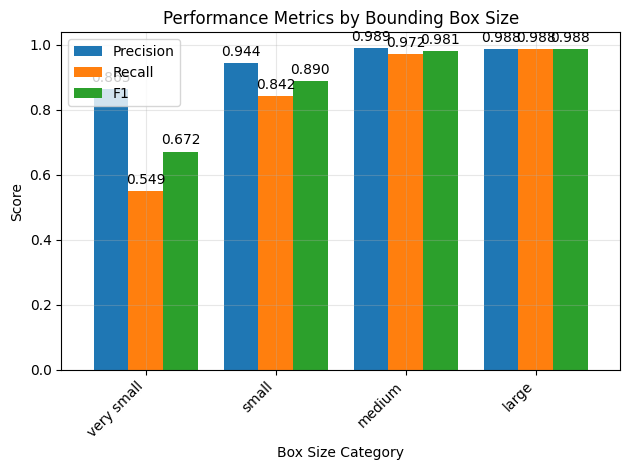

In [ ]:
# Analyze performance by size category

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from collections import defaultdict
import csv
from datetime import datetime

YOLO_MODEL = 'yolov8l'
# Define directories
BASE_DIR = './triggerfish_detection'
EXPERIMENT_NUM=f"v22"
EXPERIMENT_ID = f"{YOLO_MODEL}_dataset_v5_{EXPERIMENT_NUM}"

PROJECT = "triggerfish_detection_runs"
DATASET_PATH = './triggerfish_detection/dataset_v5'
OUTPUT_DIR = os.path.join(PROJECT, EXPERIMENT_ID)
# Define size categories
size_bins = [0, 0.0005, 0.001, 0.005, 0.1]  # Adjust these thresholds as needed
size_labels = ['very small', 'small', 'medium', 'large']
RESULTS_DIR = f'./triggerfish_detection/detection_training_runs/yolov8l_dataset_v5_v22/test_set_validation/size_analysis'

def analyze_performance_by_size():
    # Get paths
    test_images_path = Path(DATASET_PATH) / 'images/test'
    gt_path = Path(DATASET_PATH) / 'labels/test'
    
    # Create results directory if it doesn't exist
    results_dir = Path(RESULTS_DIR)
    results_dir.mkdir(parents=True, exist_ok=True)
    
    # Create CSV file for detailed results
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    csv_path = results_dir / f'detection_results_{timestamp}.csv'
    
    # Initialize debug counters
    debug_counters = defaultdict(lambda: {'gt_total': 0, 'tp': 0, 'fp': 0, 'fn': 0})
    
    # Prepare CSV headers
    csv_headers = ['image_name', 'size_category', 'prediction_type', 'confidence', 
                  'area', 'gt_box', 'pred_box', 'iou']
    
    with open(csv_path, 'w', newline='') as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=csv_headers)
        writer.writeheader()
        
        # Process each test image
        for img_file in test_images_path.glob('*.jpg'):
            # Get corresponding label file
            label_file = gt_path / f"{img_file.stem}.txt"
            
            # Get predictions for this image
            pred_results = model.predict(str(img_file), conf=0.5, verbose=False)[0]
            img_height, img_width = pred_results.orig_shape
            
            # Get ground truth boxes
            gt_boxes = []
            if label_file.exists():
                with open(label_file) as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) == 5:  # class x_center y_center width height
                            _, x, y, w, h = map(float, parts)
                            area = w * h
                            size_category = pd.cut([area], bins=size_bins, labels=size_labels)[0]
                            if size_category in size_labels:
                                debug_counters[size_category]['gt_total'] += 1
                                debug_counters[size_category]['fn'] += 1  # Will be decremented for matches
                                gt_boxes.append({
                                    'box': [x, y, w, h], 
                                    'size': size_category, 
                                    'matched': False,
                                    'area': area
                                })
            
            # Process predictions
            for box in pred_results.boxes:
                xyxy = box.xyxy[0].cpu().numpy()  # Get box in xyxy format
                conf = float(box.conf[0].cpu().numpy())  # Get confidence
                
                # Convert to normalized coordinates
                x1, y1, x2, y2 = xyxy / np.array([img_width, img_height, img_width, img_height])
                w = x2 - x1
                h = y2 - y1
                area = w * h
                
                size_category = pd.cut([area], bins=size_bins, labels=size_labels)[0]
                if size_category in size_labels:
                    # Find best matching ground truth box
                    best_iou = 0
                    best_gt_idx = -1
                    best_gt_size = None
                    
                    for idx, gt in enumerate(gt_boxes):
                        if not gt['matched']:  # Only consider unmatched ground truth boxes
                            iou = calculate_iou([x1, y1, x2, y2], gt['box'])
                            if iou > best_iou:
                                best_iou = iou
                                best_gt_idx = idx
                                best_gt_size = gt['size']
                    
                    # Record results
                    result_row = {
                        'image_name': img_file.name,
                        'size_category': size_category,
                        'confidence': conf,
                        'area': area,
                        'pred_box': f"[{x1:.4f}, {y1:.4f}, {x2:.4f}, {y2:.4f}]"
                    }
                    
                    if best_iou > 0.5:  # IOU threshold
                        # Update debug counters
                        debug_counters[best_gt_size]['tp'] += 1
                        debug_counters[best_gt_size]['fn'] -= 1
                        gt_boxes[best_gt_idx]['matched'] = True
                        
                        result_row.update({
                            'prediction_type': 'true_positive',
                            'gt_box': f"[{gt_boxes[best_gt_idx]['box'][0]:.4f}, {gt_boxes[best_gt_idx]['box'][1]:.4f}, "
                                    f"{gt_boxes[best_gt_idx]['box'][2]:.4f}, {gt_boxes[best_gt_idx]['box'][3]:.4f}]",
                            'iou': best_iou
                        })
                        print(f"Match found: {img_file.name}, GT size: {best_gt_size}, Pred size: {size_category}, IOU: {best_iou:.3f}")
                    else:
                        # Update debug counters
                        debug_counters[size_category]['fp'] += 1
                        
                        result_row.update({
                            'prediction_type': 'false_positive',
                            'gt_box': '',
                            'iou': best_iou
                        })
                        print(f"False positive: {img_file.name}, Pred size: {size_category}, Best IOU: {best_iou:.3f}")
                    
                    writer.writerow(result_row)
            
            # Record false negatives
            for gt in gt_boxes:
                if not gt['matched']:
                    writer.writerow({
                        'image_name': img_file.name,
                        'size_category': gt['size'],
                        'prediction_type': 'false_negative',
                        'confidence': 0.0,
                        'area': gt['area'],
                        'gt_box': f"[{gt['box'][0]:.4f}, {gt['box'][1]:.4f}, {gt['box'][2]:.4f}, {gt['box'][3]:.4f}]",
                        'pred_box': '',
                        'iou': 0.0
                    })

    # Print debug information
    print("\nDetailed Counters:")
    for size in size_labels:
        counts = debug_counters[size]
        print(f"\n{size} category:")
        print(f"Ground Truth Total: {counts['gt_total']}")
        print(f"True Positives: {counts['tp']}")
        print(f"False Positives: {counts['fp']}")
        print(f"False Negatives: {counts['fn']}")
        print(f"TP + FN = {counts['tp'] + counts['fn']} (should equal GT total)")

    # Calculate final metrics
    results = {}
    for size in size_labels:
        counts = debug_counters[size]
        total_gt = counts['gt_total']
        tp = counts['tp']
        fp = counts['fp']
        fn = counts['fn']
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        results[size] = {
            'Total Objects': total_gt,
            'Precision': precision,
            'Recall': recall,
            'F1': f1
        }
    
    # Save summary metrics
    metrics_df = pd.DataFrame(results).T
    metrics_df.to_csv(results_dir / f'summary_metrics_{timestamp}.csv')
    
    return metrics_df

def calculate_iou(box1, box2):
    """Calculate IOU between boxes (xyxy format for box1, xywh format for box2)"""
    # Convert box2 from xywh to xyxy format
    x_center, y_center, w, h = box2
    box2_xyxy = np.array([
        x_center - w/2,
        y_center - h/2,
        x_center + w/2,
        y_center + h/2
    ])
    
    # Calculate intersection
    x1 = max(box1[0], box2_xyxy[0])
    y1 = max(box1[1], box2_xyxy[1])
    x2 = min(box1[2], box2_xyxy[2])
    y2 = min(box1[3], box2_xyxy[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    
    # Calculate areas
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = w * h
    
    # Calculate IOU
    union = area1 + area2 - intersection
    return intersection / union if union > 0 else 0

# Calculate and display metrics
metrics_df = analyze_performance_by_size()
print("\nPerformance Metrics by Size:")
print(metrics_df.round(3))

# Create and display the plot
plt.figure(figsize=(12, 6))
ax = metrics_df[['Precision', 'Recall', 'F1']].plot(kind='bar', width=0.8)
plt.title('Performance Metrics by Bounding Box Size')
plt.xlabel('Box Size Category')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

# Adjust layout to prevent label cutoff
plt.tight_layout()

 # Save the plot
save_dir = Path('./triggerfish_detection/detection_training_runs/confidence_analysis')
save_dir.mkdir(parents=True, exist_ok=True)
    
# Generate timestamp
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
save_path = save_dir / f'confidence_histogram_size_{CONFIG["area_threshold"]:.6f}_{timestamp}.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\nSaved plot to: {save_path}")

# Display the plot
plt.show()

## 5. Compare the performance of the two models

### 5.1 Standard Metrics Comparison


In [10]:
def compare_model_results(experiments_and_results):
    """
    Compare metrics between different experiments and their result directories
    Args:
        experiments_and_results (list): List of tuples containing (experiment_id, results_num)
    """
    base_path = './triggerfish_detection/detection_training_runs'
    all_metrics = {}
    
    # Create shorter names for display
    display_names = {}
    for exp_id, res_num in experiments_and_results:
        short_name = f"Model {exp_id[-2:]} res{res_num}" if exp_id[-2:].isdigit() else f"Model {exp_id[-1]} res{res_num}"
        display_names[f'{exp_id}_results{res_num}'] = short_name
    
    # Load metrics
    for exp_id, res_num in experiments_and_results:
        metrics_path = Path(base_path) / exp_id / 'test_set_validation' / f'results{res_num}' / 'metrics.json'
        exp_name = f'{exp_id}_results{res_num}'
        
        try:
            with open(metrics_path, 'r') as f:
                metrics = json.load(f)
                all_metrics[exp_name] = metrics
                print(f"Loaded metrics from: Model {exp_id[-2:]} results{res_num}")
        except FileNotFoundError:
            print(f"No metrics file found for {metrics_path}")
            continue
    
    # Print comparison
    if all_metrics:
        # Get all metric names
        metric_names = list(next(iter(all_metrics.values())).keys())
        
        # Calculate column width based on display names
        col_width = max(20, max(len(name) for name in display_names.values()) + 5)
        
        # Print header
        print("\nMetrics Comparison:")
        separator = "-" * (15 + (col_width + 3) * len(experiments_and_results))
        print(separator)
        
        # Create header with shortened names
        header = "Metric".ljust(15) + " | "
        header += " | ".join(display_names[f'{exp_id}_results{res_num}'].ljust(col_width)
                           for exp_id, res_num in experiments_and_results)
        print(header)
        print(separator)
        
        # Print each metric
        for metric in metric_names:
            row = metric.ljust(15) + " | "
            for exp_id, res_num in experiments_and_results:
                exp_name = f'{exp_id}_results{res_num}'
                if exp_name in all_metrics:
                    value = all_metrics[exp_name][metric]
                    row += f"{value:.3f}".ljust(col_width) + " | "
                else:
                    row += "N/A".ljust(col_width) + " | "
            print(row)
        print(separator)
        
        # Calculate and print differences
        if len(experiments_and_results) == 2:
            print("\nDifferences (Second - First):")
            print("-" * 40)
            exp1_name = f'{experiments_and_results[0][0]}_results{experiments_and_results[0][1]}'
            exp2_name = f'{experiments_and_results[1][0]}_results{experiments_and_results[1][1]}'
            
            for metric in metric_names:
                if exp1_name in all_metrics and exp2_name in all_metrics:
                    diff = all_metrics[exp2_name][metric] - all_metrics[exp1_name][metric]
                    print(f"{metric.ljust(15)}: {diff:+.3f}")
    else:
        print("No metrics found to compare")

# Example usage
if __name__ == "__main__":
    experiments_to_compare = [
        ("yolov8l_dataset_v5_v1", 1),
        ("yolov8l_dataset_v5_v22", 1)
    ]
    compare_model_results(experiments_to_compare)

Loaded metrics from: Model v1 results1
Loaded metrics from: Model 22 results1

Metrics Comparison:
-------------------------------------------------------------
Metric          | Model 1 res1         | Model 22 res1       
-------------------------------------------------------------
mAP50           | 0.951                | 0.961                | 
mAP50-95        | 0.604                | 0.618                | 
Precision       | 0.943                | 0.939                | 
Recall          | 0.887                | 0.916                | 
F1-Score        | 0.914                | 0.927                | 
-------------------------------------------------------------

Differences (Second - First):
----------------------------------------
mAP50          : +0.011
mAP50-95       : +0.014
Precision      : -0.004
Recall         : +0.029
F1-Score       : +0.013


In [ ]:
from ultralytics import YOLO
import torch
import json
from pathlib import Path

def load_val_results(results_path):
    """Load validation results from a saved JSON file"""
    with open(results_path) as f:
        results = json.load(f)
    return results

def compare_saved_metrics(results1_path, results2_path):
    """
    Compare two YOLO models using their saved validation results
    
    Args:
        results1_path: Path to first model's validation results JSON
        results2_path: Path to second model's validation results JSON
    """
    # Load saved results
    results1 = load_val_results(results1_path)
    results2 = load_val_results(results2_path)
    
    # Extract metrics
    metrics = {
        'Model 1': {
            'mAP50': results1['metrics/mAP50(B)'],
            'mAP50-95': results1['metrics/mAP50-95(B)'],
            'Precision': results1['metrics/precision(B)'],
            'Recall': results1['metrics/recall(B)'],
            'F1-Score': 2 * (results1['metrics/precision(B)'] * results1['metrics/recall(B)']) / 
                         (results1['metrics/precision(B)'] + results1['metrics/recall(B)])
        },
        'Model 2': {
            'mAP50': results2['metrics/mAP50(B)'],
            'mAP50-95': results2['metrics/mAP50-95(B)'],
            'Precision': results2['metrics/precision(B)'],
            'Recall': results2['metrics/recall(B)'],
            'F1-Score': 2 * (results2['metrics/precision(B)'] * results2['metrics/recall(B)']) / 
                         (results2['metrics/precision(B)'] + results2['metrics/recall(B)])
        }
    }
    
    return metrics

# Example usage:
MODEL1_RESULTS = "triggerfish_detection/detection_training_runs/yolov8x_dataset_v5_v1/test_set_validation/results.json"
MODEL2_RESULTS = "triggerfish_detection/detection_training_runs/yolov8m_dataset_v5_v1/test_set_validation/results.json"

try:
    comparison = compare_saved_metrics(MODEL1_RESULTS, MODEL2_RESULTS)
    
    print("\nModel Comparison:")
    print("-" * 50)
    metrics_list = ['mAP50', 'mAP50-95', 'Precision', 'Recall', 'F1-Score']
    
    for metric in metrics_list:
        print(f"\n{metric}:")
        print(f"Model 1: {comparison['Model 1'][metric]:.3f}")
        print(f"Model 2: {comparison['Model 2'][metric]:.3f}")
        diff = comparison['Model 2'][metric] - comparison['Model 1'][metric]
        print(f"Difference: {diff:+.3f}")

except Exception as e:
    print(f"Error during model comparison: {e}")

### 5.2 Size-based Performance Comparison

<b>Note: This might not be working.</b> The values don't match the previous plots and I haven't checked them. 

In [18]:
%matplotlib inline

def analyze_detections_by_size(experiments_and_results):
    """
    Compare detection performance across different object sizes for multiple models
    """
    base_path = './triggerfish_detection/detection_training_runs'
    dataset_path = './triggerfish_detection/dataset_v5'
    
    # Define size thresholds (area as proportion of image)
    size_thresholds = {
        'very_small': (0, 0.0005),
        'small': (0.0005, 0.001),
        'medium': (0.001, 0.005),
        'large': (0.005, 0.1)
    } 
    # Store results for each model
    model_results = {}
    
    for exp_id, res_num in experiments_and_results:
        # Load ground truth labels from dataset
        gt_path = Path(dataset_path) / 'labels' / 'test'
        pred_path = Path(base_path) / exp_id / 'test_set_validation' / f'results{res_num}' / 'labels'
        
        try:
            # Get all ground truth files
            gt_files = list(gt_path.glob('*.txt'))
            pred_files = list(pred_path.glob('*.txt'))
            
            print(f"\nProcessing {len(gt_files)} test files for {exp_id}")
            
            # Store all boxes
            gt_boxes = []
            pred_boxes = []
            
            # Process each image's labels
            for gt_file in gt_files:
                img_name = gt_file.stem
                pred_file = pred_path / f'{img_name}.txt'
                
                # Read ground truth
                with open(gt_file, 'r') as f:
                    for line in f:
                        class_id, x_center, y_center, width, height = map(float, line.strip().split())
                        area = width * height
                        gt_boxes.append({
                            'area': area,
                            'width': width,
                            'height': height,
                            'x_center': x_center,
                            'y_center': y_center
                        })
                
                # Read predictions if they exist
                if pred_file.exists():
                    with open(pred_file, 'r') as f:
                        for line in f:
                            # YOLO format: class x_center y_center width height confidence
                            parts = line.strip().split()
                            if len(parts) >= 6:  # Ensure we have all values including confidence
                                class_id, x_center, y_center, width, height, conf = map(float, parts[:6])
                                area = width * height
                                pred_boxes.append({
                                    'area': area,
                                    'width': width,
                                    'height': height,
                                    'x_center': x_center,
                                    'y_center': y_center,
                                    'confidence': conf
                                })
            
            # Analyze performance for each size category
            size_performance = {}
            for size_category, (min_size, max_size) in size_thresholds.items():
                # Filter boxes by size
                gt_size_boxes = [box for box in gt_boxes if min_size <= box['area'] < max_size]
                pred_size_boxes = [box for box in pred_boxes if min_size <= box['area'] < max_size]
                
                # Calculate metrics for this size category
                metrics = calculate_size_metrics(pred_size_boxes, gt_size_boxes)
                size_performance[size_category] = metrics
                
                # Print counts for verification
                print(f"\n{size_category}:")
                print(f"Ground truth boxes: {len(gt_size_boxes)}")
                print(f"Predicted boxes: {len(pred_size_boxes)}")
            
            model_results[exp_id] = size_performance
            
        except Exception as e:
            print(f"Error processing {exp_id}: {e}")
            continue
    
    # Print comparison
    print("\nSize-based Performance Comparison:")
    print("-" * 80)
    
    # Print header
    header = "Size Category".ljust(15) + " | Metric".ljust(12) + " | "
    header += " | ".join(f"Model {exp_id[-2:]}".ljust(10) for exp_id, _ in experiments_and_results)
    print(header)
    print("-" * 80)
    
    # Print metrics for each size category
    metrics_to_show = ['precision', 'recall', 'f1_score', 'count']
    for size_category in size_thresholds.keys():
        for metric in metrics_to_show:
            row = size_category.ljust(15) + " | "
            row += metric.ljust(12) + " | "
            
            for exp_id, _ in experiments_and_results:
                if exp_id in model_results and size_category in model_results[exp_id]:
                    value = model_results[exp_id][size_category][metric]
                    if metric == 'count':
                        row += f"{int(value)}".ljust(10) + " | "
                    else:
                        row += f"{value:.3f}".ljust(10) + " | "
                else:
                    row += "N/A".ljust(10) + " | "
            print(row)
        print("-" * 80)

def calculate_size_metrics(predictions, ground_truth):
    """
    Calculate precision, recall, and F1 score for a specific size category
    """
    if not ground_truth:
        return {'precision': 0, 'recall': 0, 'f1_score': 0, 'count': 0}
    
    # Match predictions to ground truth using IoU
    matches = 0
    for gt_box in ground_truth:
        for pred_box in predictions:
            if calculate_iou_from_yolo(gt_box, pred_box) > 0.5:  # IoU threshold
                matches += 1
                break
    
    precision = matches / len(predictions) if predictions else 0
    recall = matches / len(ground_truth) if ground_truth else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'count': len(ground_truth)  # Count of ground truth boxes in this category
    }

def calculate_iou_from_yolo(box1, box2):
    """
    Calculate IoU between two boxes in YOLO format (normalized coordinates)
    """
    # Convert center coordinates to corners
    box1_x1 = box1['x_center'] - box1['width']/2
    box1_y1 = box1['y_center'] - box1['height']/2
    box1_x2 = box1['x_center'] + box1['width']/2
    box1_y2 = box1['y_center'] + box1['height']/2
    
    box2_x1 = box2['x_center'] - box2['width']/2
    box2_y1 = box2['y_center'] - box2['height']/2
    box2_x2 = box2['x_center'] + box2['width']/2
    box2_y2 = box2['y_center'] + box2['height']/2
    
    # Calculate intersection coordinates
    x1 = max(box1_x1, box2_x1)
    y1 = max(box1_y1, box2_y1)
    x2 = min(box1_x2, box2_x2)
    y2 = min(box1_y2, box2_y2)
    
    # Calculate intersection area
    if x2 <= x1 or y2 <= y1:
        return 0
    intersection = (x2 - x1) * (y2 - y1)
    
    # Calculate union area
    area1 = box1['width'] * box1['height']
    area2 = box2['width'] * box2['height']
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0

# Example usage
if __name__ == "__main__":
    experiments_to_compare = [
        ("yolov8l_dataset_v5_v1", 1),
        ("yolov8l_dataset_v5_v22", 1)
    ]
    analyze_detections_by_size(experiments_to_compare)


Processing 1011 test files for yolov8l_dataset_v5_v1

very_small:
Ground truth boxes: 315
Predicted boxes: 8754

small:
Ground truth boxes: 278
Predicted boxes: 2874

medium:
Ground truth boxes: 941
Predicted boxes: 1575

large:
Ground truth boxes: 328
Predicted boxes: 362

Processing 1011 test files for yolov8l_dataset_v5_v22

very_small:
Ground truth boxes: 315
Predicted boxes: 6620

small:
Ground truth boxes: 278
Predicted boxes: 1981

medium:
Ground truth boxes: 941
Predicted boxes: 1304

large:
Ground truth boxes: 328
Predicted boxes: 400

Size-based Performance Comparison:
--------------------------------------------------------------------------------
Size Category   | Metric    | Model v1   | Model 22  
--------------------------------------------------------------------------------
very_small      | precision    | 0.033      | 0.044      | 
very_small      | recall       | 0.921      | 0.930      | 
very_small      | f1_score     | 0.064      | 0.084      | 
very_small      |

### 5.3 Confidence-based Performance Comparison

I want to test what the model confidence is for these different detection types: 

* <b>Positive:</b> True Positive (TP): Correct detection of a triggerfish.
* <b>False Positive (FP):</b> Incorrect detection of a triggerfish.
* <b>False Negative (FN):</b> Incorrect non-detection of a triggerfish.
* <b>True Negative (TN):</b> Correct non-detection of a triggerfish. Also called Background on a confusion matrix.

False Negatives and True Negatives do not have a confidence score because they are not detections.

I can plot the confidence of the model for the other two types of detection.

<b> AIM: I want to find a minimum confidence threshold that will give me a good balance between precision and recall. </b>


#### 5.3.1 Historgram of confidence by model and detection type


Suspicious match found in image_2877:
Confidence: 0.0440744
IoU: 0.7053970656071206

Suspicious match found in image_2877:
Confidence: 0.0390029
IoU: 0.5388314703049882

Suspicious match found in image_2877:
Confidence: 0.00529974
IoU: 0.5765828303257683

Suspicious match found in image_2877:
Confidence: 0.00213128
IoU: 0.5680680408955135

Suspicious match found in image_2877:
Confidence: 0.00185177
IoU: 0.5908418624519077

Suspicious match found in image_2877:
Confidence: 0.00151624
IoU: 0.5718445919300164

Suspicious match found in image_8602:
Confidence: 0.0352186
IoU: 0.5729810886124561

Suspicious match found in image_8602:
Confidence: 0.0069349
IoU: 0.5356877393019495

Suspicious match found in image_8602:
Confidence: 0.0052364
IoU: 0.660753934324278

Suspicious match found in image_8602:
Confidence: 0.00259065
IoU: 0.7325788248199084

Suspicious match found in image_8602:
Confidence: 0.00152911
IoU: 0.7433772399333353

Suspicious match found in image_1327:
Confidence: 0.0010332

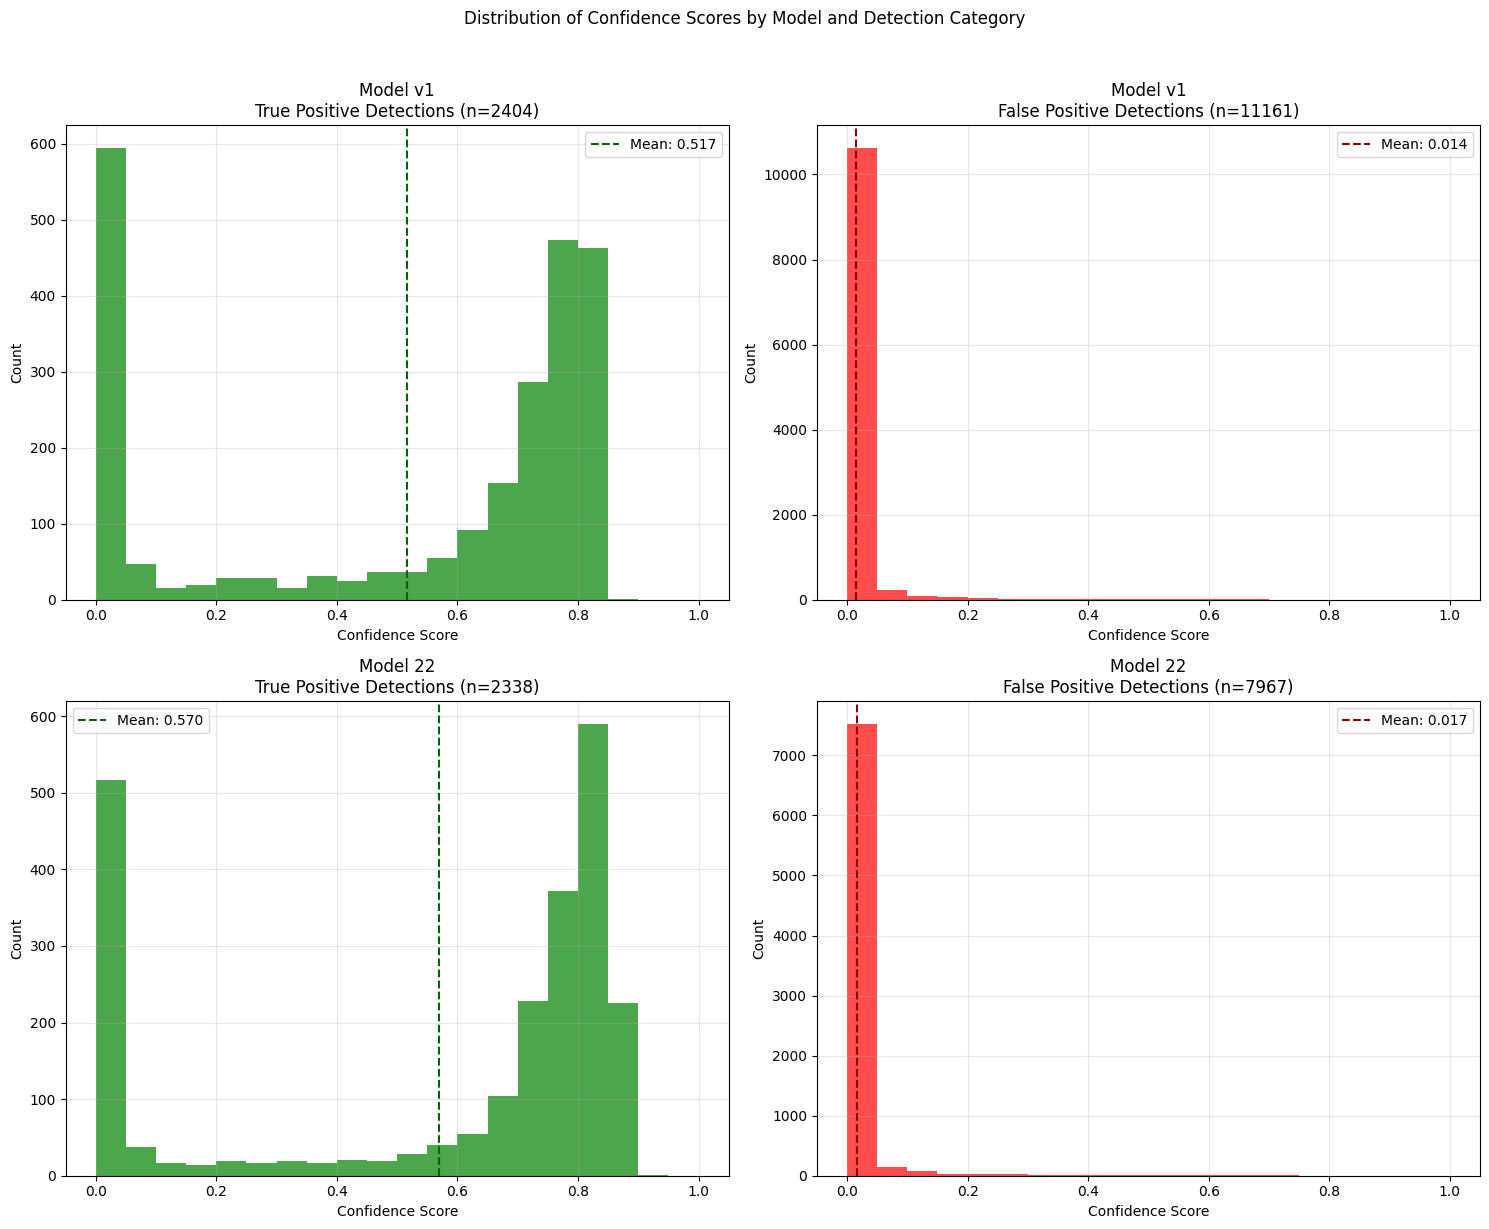


Saved histogram plot to: triggerfish_detection/detection_training_runs/confidence_analysis/confidence_histogram_by_model.png


<Figure size 640x480 with 0 Axes>

In [32]:
def analyze_confidence_by_detection_type(experiments_and_results):
    """
    Analyze and plot confidence scores for different detection categories using histograms
    with additional validation checks
    """
    base_path = './triggerfish_detection/detection_training_runs'
    plot_data = []
    
    for exp_id, res_num in experiments_and_results:
        pred_path = Path(base_path) / exp_id / 'test_set_validation' / f'results{res_num}' / 'labels'
        gt_path = Path('./triggerfish_detection/dataset_v5/labels/test')
        
        # Debug counters
        total_predictions = 0
        total_gt = 0
        suspicious_matches = 0
        
        try:
            for pred_file in pred_path.glob('*.txt'):
                img_name = pred_file.stem
                gt_file = gt_path / f'{img_name}.txt'
                
                # Read ground truth boxes
                gt_boxes = []
                if gt_file.exists():
                    with open(gt_file, 'r') as f:
                        for line in f:
                            parts = line.strip().split()
                            if len(parts) >= 5:
                                class_id, x_center, y_center, width, height = map(float, parts[:5])
                                gt_boxes.append({
                                    'x': x_center,
                                    'y': y_center,
                                    'width': width,
                                    'height': height
                                })
                total_gt += len(gt_boxes)
                
                # Read and validate predictions
                pred_boxes = []
                with open(pred_file, 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 6:
                            class_id, x_center, y_center, width, height, conf = map(float, parts[:6])
                            
                            # Validate confidence score
                            if conf <= 0 or conf > 1:
                                print(f"Warning: Invalid confidence score {conf} in {pred_file}")
                                continue
                                
                            pred_boxes.append({
                                'x': x_center,
                                'y': y_center,
                                'width': width,
                                'height': height,
                                'confidence': conf
                            })
                total_predictions += len(pred_boxes)
                
                # Match predictions to ground truth with validation
                for pred in pred_boxes:
                    best_iou = 0
                    is_tp = False
                    
                    for gt_box in gt_boxes:
                        iou = calculate_iou(pred, gt_box)
                        if iou > best_iou:
                            best_iou = iou
                    
                    if best_iou > 0.5:
                        is_tp = True
                        if pred['confidence'] < 0.1:  # Flag suspicious matches
                            suspicious_matches += 1
                            print(f"\nSuspicious match found in {img_name}:")
                            print(f"Confidence: {pred['confidence']}")
                            print(f"IoU: {best_iou}")
                    
                    plot_data.append({
                        'Model': f'Model {exp_id[-2:]}',
                        'Category': 'True Positive' if is_tp else 'False Positive',
                        'Confidence': pred['confidence'],
                        'IoU': best_iou
                    })
            
            print(f"\nProcessed {exp_id}:")
            print(f"Total predictions: {total_predictions}")
            print(f"Total ground truth boxes: {total_gt}")
            print(f"Suspicious matches (TP with conf < 0.1): {suspicious_matches}")
            
        except Exception as e:
            print(f"Error processing {exp_id}: {e}")
            continue
    
    # Convert to DataFrame
    df = pd.DataFrame(plot_data)
    
    # Create figure with subplots (2x2 grid)
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot settings
    bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1
    colors = {'True Positive': 'green', 'False Positive': 'red'}
    
    # Plot for each model
    for i, model in enumerate(df['Model'].unique()):
        model_data = df[df['Model'] == model]
        
        # True Positives
        tp_data = model_data[model_data['Category'] == 'True Positive']['Confidence']
        axes[i, 0].hist(tp_data, bins=bins, color=colors['True Positive'], alpha=0.7)
        axes[i, 0].set_title(f'{model}\nTrue Positive Detections (n={len(tp_data)})')
        axes[i, 0].set_xlabel('Confidence Score')
        axes[i, 0].set_ylabel('Count')
        axes[i, 0].grid(True, alpha=0.3)
        
        # Add mean line
        if len(tp_data) > 0:
            mean_tp = tp_data.mean()
            axes[i, 0].axvline(mean_tp, color='darkgreen', linestyle='--', 
                             label=f'Mean: {mean_tp:.3f}')
            axes[i, 0].legend()
        
        # False Positives
        fp_data = model_data[model_data['Category'] == 'False Positive']['Confidence']
        axes[i, 1].hist(fp_data, bins=bins, color=colors['False Positive'], alpha=0.7)
        axes[i, 1].set_title(f'{model}\nFalse Positive Detections (n={len(fp_data)})')
        axes[i, 1].set_xlabel('Confidence Score')
        axes[i, 1].set_ylabel('Count')
        axes[i, 1].grid(True, alpha=0.3)
        
        # Add mean line
        if len(fp_data) > 0:
            mean_fp = fp_data.mean()
            axes[i, 1].axvline(mean_fp, color='darkred', linestyle='--', 
                             label=f'Mean: {mean_fp:.3f}')
            axes[i, 1].legend()
        
        # Print statistics
        for category in ['True Positive', 'False Positive']:
            stats = model_data[model_data['Category'] == category]['Confidence'].describe()
            print(f"\n{model} - {category}:")
            print(f"Count: {stats['count']:.0f}")
            print(f"Mean: {stats['mean']:.3f}")
            print(f"Std: {stats['std']:.3f}")
            print(f"Min: {stats['min']:.3f}")
            print(f"Max: {stats['max']:.3f}")
            print(f"25%: {stats['25%']:.3f}")
            print(f"50%: {stats['50%']:.3f}")
            print(f"75%: {stats['75%']:.3f}")
    
    plt.suptitle('Distribution of Confidence Scores by Model and Detection Category', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Save the plot
    save_dir = Path(base_path) / 'confidence_analysis'
    save_dir.mkdir(exist_ok=True)
    save_path = save_dir / f'confidence_histogram_by_model.png'
    plt.savefig(save_path)
    print(f"\nSaved histogram plot to: {save_path}")

# Rest of the code (calculate_iou function) remains the same

# Example usage
if __name__ == "__main__":
    experiments_to_compare = [
        ("yolov8l_dataset_v5_v1", 1),
        ("yolov8l_dataset_v5_v22", 1)
    ]
    analyze_confidence_by_detection_type(experiments_to_compare)

#### 5.3.2 Plotting predictions with a confidence of 0
In these historgrams, the True Positives detections have a large number of detections with a confidence of 0. This seems unusual. 

To investigate this, I will plot the predictions on an image with a confidence of 0. 

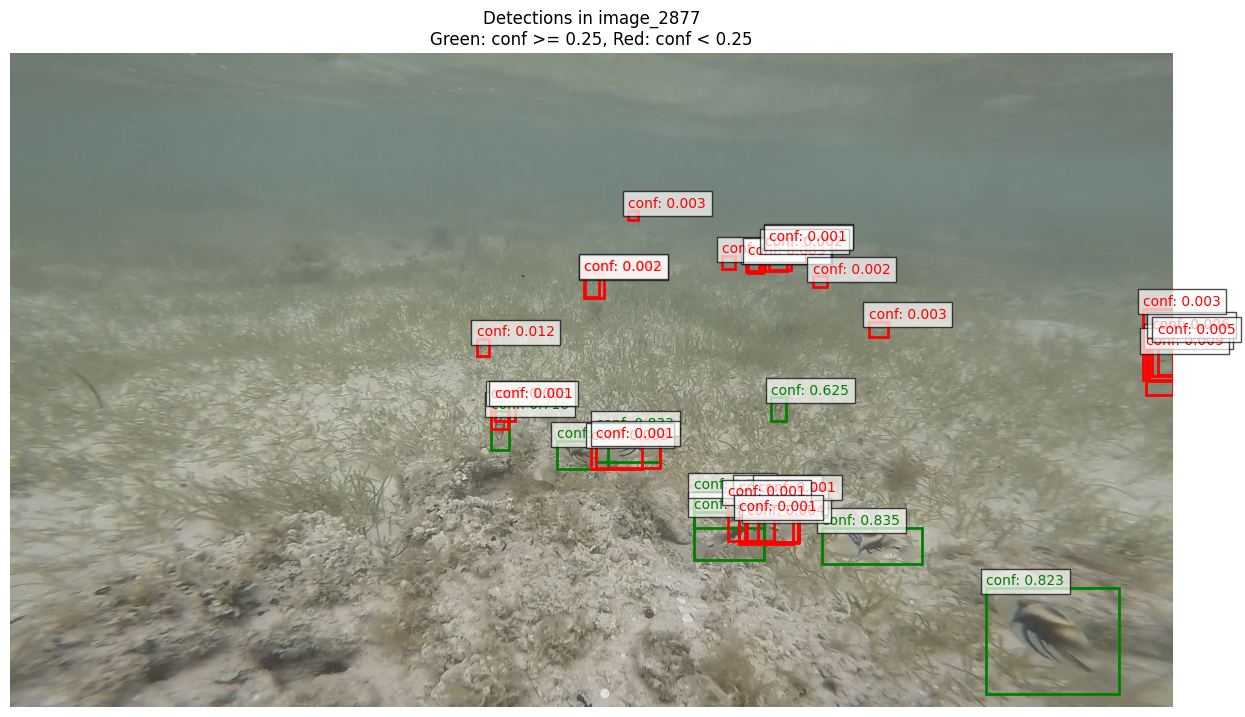


Confidence values:
✓ 0.840752
✓ 0.835198
✓ 0.832782
✓ 0.822663
✓ 0.809335
✓ 0.776105
✓ 0.726104
✓ 0.716429
✓ 0.625411
✗ 0.045942
✗ 0.031403
✗ 0.014366
✗ 0.013616
✗ 0.013076
✗ 0.011888
✗ 0.009138
✗ 0.009064
✗ 0.005935
✗ 0.005017
✗ 0.003659
✗ 0.003436
✗ 0.003292
✗ 0.003192
✗ 0.003149
✗ 0.003028
✗ 0.002613
✗ 0.002511
✗ 0.002409
✗ 0.001856
✗ 0.001735
✗ 0.001435
✗ 0.001350
✗ 0.001289
✗ 0.001242
✗ 0.001108
✗ 0.001059


In [31]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def plot_predictions(image_path, model, conf_threshold=0.25):
    # Load image
    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f"Could not read image at {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Get predictions
    results = model.predict(
        source=image_path,
        conf=0.001,  # Set very low to see all predictions
        verbose=False
    )[0]
    
    # Create figure and axes
    fig, ax = plt.subplots(1, figsize=(15, 10))
    
    # Display image
    ax.imshow(img)
    
    # Plot predictions
    boxes = results.boxes
    for box in boxes:
        # Get coordinates and confidence
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        conf = float(box.conf)
        
        # Choose color based on confidence threshold
        color = 'green' if conf >= conf_threshold else 'red'
        
        # Create rectangle patch
        width = x2 - x1
        height = y2 - y1
        rect = plt.Rectangle((x1, y1), width, height, fill=False, color=color, linewidth=2)
        ax.add_patch(rect)
        
        # Add confidence score
        ax.text(x1, y1-5, f'conf: {conf:.3f}', color=color, 
                bbox=dict(facecolor='white', alpha=0.7))
    
    ax.set_title(f'Detections in image_2877\nGreen: conf >= {conf_threshold}, Red: conf < {conf_threshold}')
    plt.axis('off')
    plt.show()
    
    # Print confidence values
    print("\nConfidence values:")
    for box in boxes:
        conf = float(box.conf)
        print(f"{'✓' if conf >= conf_threshold else '✗'} {conf:.6f}")

# Load model
model = YOLO('./triggerfish_detection/detection_training_runs/yolov8l_dataset_v5_v22/weights/best.pt')

# Plot predictions
image_path = Path('./triggerfish_detection/dataset_v5/images/test/image_2877.jpg')
plot_predictions(image_path, model, conf_threshold=0.25)

#### 5.3.3 Plotting predictions with a confidence of > 0.25

The True positive predictions with a confidence <0.25 are garbage so we can ignore them. 

Repeat histogram of confidence by model and detection type but only plot the True Positive and False Positive predictions with a confidence > 0.25. 


Processed yolov8l_dataset_v5_v1:
Total predictions (conf >= 0.25): 1821
Total ground truth boxes: 1862

Processed yolov8l_dataset_v5_v22:
Total predictions (conf >= 0.25): 1872
Total ground truth boxes: 1861

Model v1 - True Positive:
Count: 1697
Mean: 0.719
Std: 0.123
Min: 0.252
Max: 0.852
25%: 0.688
50%: 0.761
75%: 0.803

Model v1 - False Positive:
Count: 124
Mean: 0.444
Std: 0.132
Min: 0.259
Max: 0.843
25%: 0.347
50%: 0.408
75%: 0.508

Model 22 - True Positive:
Count: 1735
Mean: 0.759
Std: 0.118
Min: 0.254
Max: 0.900
25%: 0.730
50%: 0.795
75%: 0.835

Model 22 - False Positive:
Count: 137
Mean: 0.454
Std: 0.144
Min: 0.251
Max: 0.812
25%: 0.326
50%: 0.430
75%: 0.563


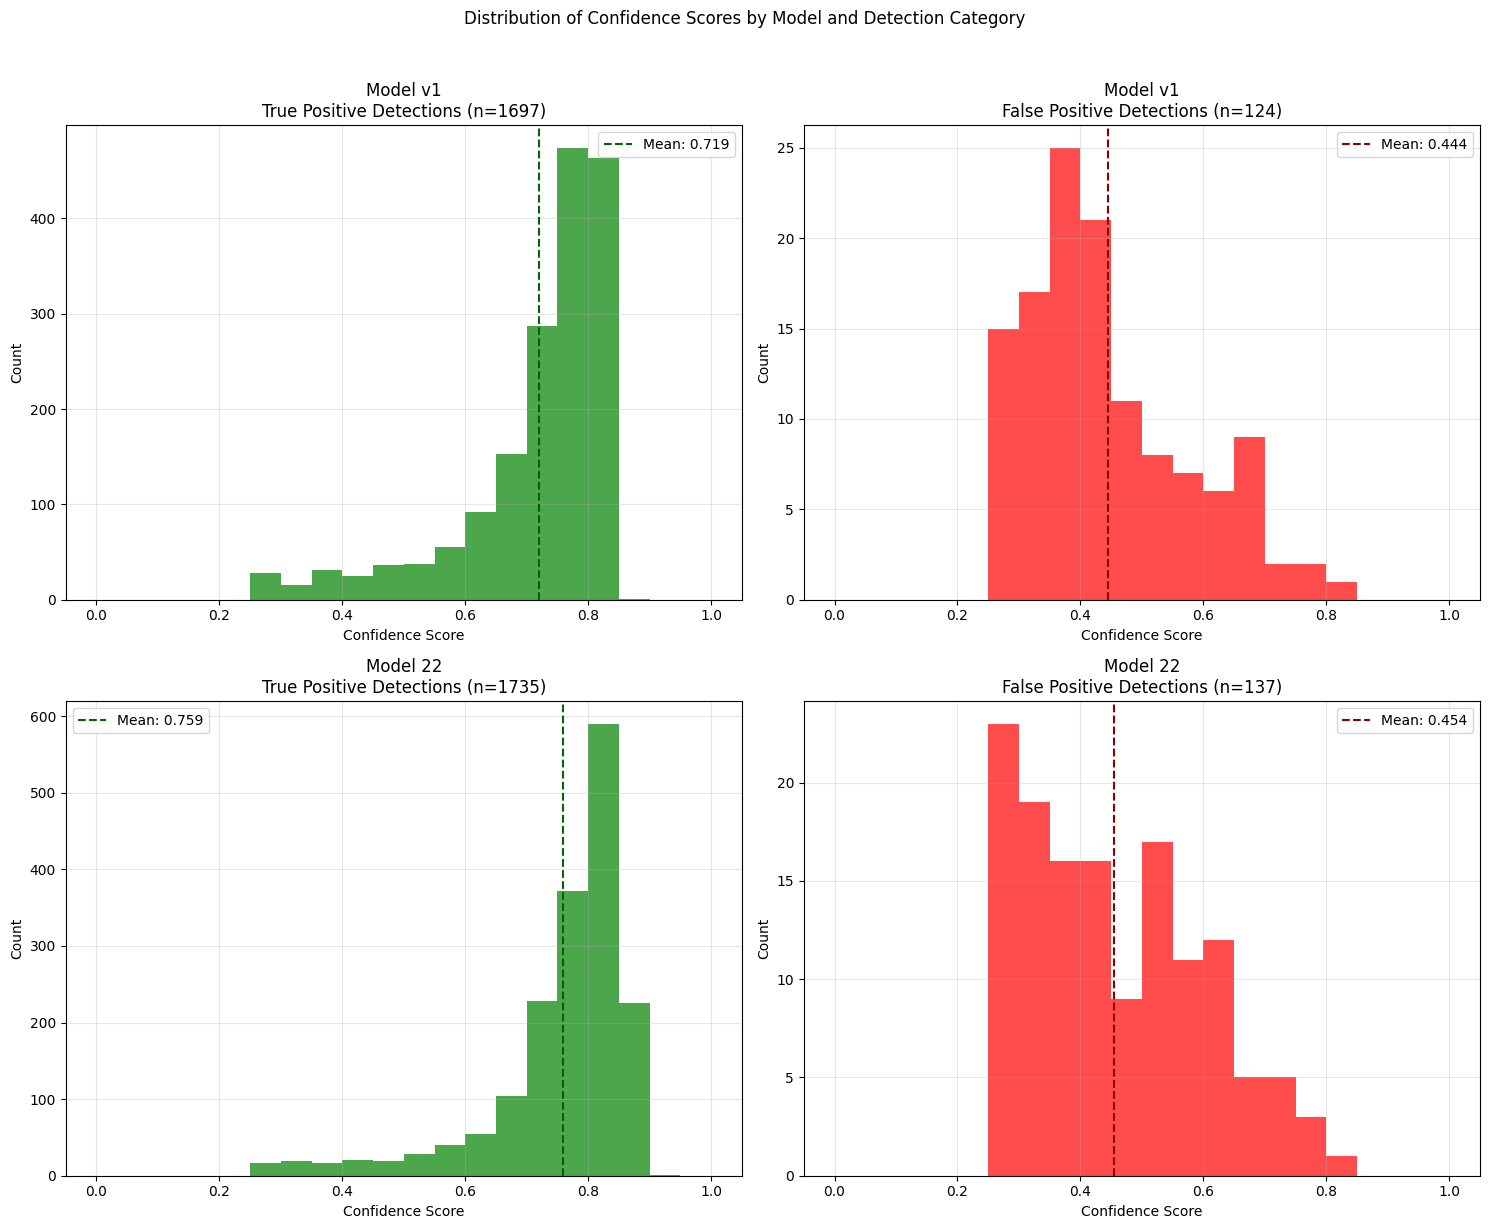


Saved histogram plot to: triggerfish_detection/detection_training_runs/confidence_analysis/confidence_histogram_by_model.png


<Figure size 640x480 with 0 Axes>

In [35]:
def analyze_confidence_by_detection_type(experiments_and_results):
    """
    Analyze and plot confidence scores for different detection categories using histograms
    """
    base_path = './triggerfish_detection/detection_training_runs'
    plot_data = []
    
    for exp_id, res_num in experiments_and_results:
        pred_path = Path(base_path) / exp_id / 'test_set_validation' / f'results{res_num}' / 'labels'
        gt_path = Path('./triggerfish_detection/dataset_v5/labels/test')
        
        # Debug counters
        total_predictions = 0
        total_gt = 0
        
        try:
            for pred_file in pred_path.glob('*.txt'):
                img_name = pred_file.stem
                gt_file = gt_path / f'{img_name}.txt'
                
                # Read ground truth boxes
                gt_boxes = []
                if gt_file.exists():
                    with open(gt_file, 'r') as f:
                        for line in f:
                            parts = line.strip().split()
                            if len(parts) >= 5:
                                class_id, x_center, y_center, width, height = map(float, parts[:5])
                                gt_boxes.append({
                                    'x': x_center,
                                    'y': y_center,
                                    'width': width,
                                    'height': height
                                })
                total_gt += len(gt_boxes)
                
                # Read and validate predictions
                pred_boxes = []
                with open(pred_file, 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 6:
                            class_id, x_center, y_center, width, height, conf = map(float, parts[:6])
                            
                            # Skip predictions with confidence < 0.25
                            if conf < 0.25:
                                continue
                                
                            pred_boxes.append({
                                'x': x_center,
                                'y': y_center,
                                'width': width,
                                'height': height,
                                'confidence': conf
                            })
                total_predictions += len(pred_boxes)
                
                # Match predictions to ground truth
                for pred in pred_boxes:
                    best_iou = 0
                    is_tp = False
                    
                    for gt_box in gt_boxes:
                        iou = calculate_iou(pred, gt_box)
                        if iou > best_iou:
                            best_iou = iou
                    
                    if best_iou > 0.5:
                        is_tp = True
                    
                    plot_data.append({
                        'Model': f'Model {exp_id[-2:]}',
                        'Category': 'True Positive' if is_tp else 'False Positive',
                        'Confidence': pred['confidence'],
                        'IoU': best_iou
                    })
            
            print(f"\nProcessed {exp_id}:")
            print(f"Total predictions (conf >= 0.25): {total_predictions}")
            print(f"Total ground truth boxes: {total_gt}")
            
        except Exception as e:
            print(f"Error processing {exp_id}: {e}")
            continue
    
    # Convert to DataFrame
    df = pd.DataFrame(plot_data)
    
    # Create figure with subplots (2x2 grid)
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot settings
    bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1
    colors = {'True Positive': 'green', 'False Positive': 'red'}
    
    # Plot for each model
    for i, model in enumerate(df['Model'].unique()):
        model_data = df[df['Model'] == model]
        
        # True Positives
        tp_data = model_data[model_data['Category'] == 'True Positive']['Confidence']
        axes[i, 0].hist(tp_data, bins=bins, color=colors['True Positive'], alpha=0.7)
        axes[i, 0].set_title(f'{model}\nTrue Positive Detections (n={len(tp_data)})')
        axes[i, 0].set_xlabel('Confidence Score')
        axes[i, 0].set_ylabel('Count')
        axes[i, 0].grid(True, alpha=0.3)
        
        if len(tp_data) > 0:
            mean_tp = tp_data.mean()
            axes[i, 0].axvline(mean_tp, color='darkgreen', linestyle='--', 
                             label=f'Mean: {mean_tp:.3f}')
            axes[i, 0].legend()
        
        # False Positives
        fp_data = model_data[model_data['Category'] == 'False Positive']['Confidence']
        axes[i, 1].hist(fp_data, bins=bins, color=colors['False Positive'], alpha=0.7)
        axes[i, 1].set_title(f'{model}\nFalse Positive Detections (n={len(fp_data)})')
        axes[i, 1].set_xlabel('Confidence Score')
        axes[i, 1].set_ylabel('Count')
        axes[i, 1].grid(True, alpha=0.3)
        
        if len(fp_data) > 0:
            mean_fp = fp_data.mean()
            axes[i, 1].axvline(mean_fp, color='darkred', linestyle='--', 
                             label=f'Mean: {mean_fp:.3f}')
            axes[i, 1].legend()
        
        # Print statistics
        for category in ['True Positive', 'False Positive']:
            stats = model_data[model_data['Category'] == category]['Confidence'].describe()
            print(f"\n{model} - {category}:")
            print(f"Count: {stats['count']:.0f}")
            print(f"Mean: {stats['mean']:.3f}")
            print(f"Std: {stats['std']:.3f}")
            print(f"Min: {stats['min']:.3f}")
            print(f"Max: {stats['max']:.3f}")
            print(f"25%: {stats['25%']:.3f}")
            print(f"50%: {stats['50%']:.3f}")
            print(f"75%: {stats['75%']:.3f}")
    
    plt.suptitle('Distribution of Confidence Scores by Model and Detection Category', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Save the plot
    save_dir = Path(base_path) / 'confidence_analysis'
    save_dir.mkdir(exist_ok=True)
    save_path = save_dir / f'confidence_histogram_by_model.png'
    plt.savefig(save_path)
    print(f"\nSaved histogram plot to: {save_path}")

def calculate_iou(box1, box2):
    """Calculate IoU between two boxes in normalized coordinates"""
    # Convert from center format to corner format
    box1_x1 = box1['x'] - box1['width']/2
    box1_y1 = box1['y'] - box1['height']/2
    box1_x2 = box1['x'] + box1['width']/2
    box1_y2 = box1['y'] + box1['height']/2
    
    box2_x1 = box2['x'] - box2['width']/2
    box2_y1 = box2['y'] - box2['height']/2
    box2_x2 = box2['x'] + box2['width']/2
    box2_y2 = box2['y'] + box2['height']/2
    
    # Calculate intersection
    x1 = max(box1_x1, box2_x1)
    y1 = max(box1_y1, box2_y1)
    x2 = min(box1_x2, box2_x2)
    y2 = min(box1_y2, box2_y2)
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    
    # Calculate union
    box1_area = (box1_x2 - box1_x1) * (box1_y2 - box1_y1)
    box2_area = (box2_x2 - box2_x1) * (box2_y2 - box2_y1)
    union = box1_area + box2_area - intersection
    
    # Calculate IoU
    if union <= 0:
        return 0
    return intersection / union

# Call the function with your experiments
if __name__ == "__main__":
    experiments_to_compare = [
        ("yolov8l_dataset_v5_v1", 1),
        ("yolov8l_dataset_v5_v22", 1)
    ]
    
    # Make sure pandas and matplotlib are imported
    import pandas as pd
    import matplotlib.pyplot as plt
    
    # Call the function
    analyze_confidence_by_detection_type(experiments_to_compare)

<b> The above plots the mean confidence of the model for each detection type. I want to find a minimum confidence threshold that is unlikely to include any False Positives while also getting as many True Positives as possible. </b>

#### 5.3.4 Finding the highest confidence False Positive

In [37]:
def find_highest_fp_confidence(experiments_and_results):
    """
    Find the highest confidence false positive detection for each model
    """
    base_path = './triggerfish_detection/detection_training_runs'
    
    for exp_id, res_num in experiments_and_results:
        pred_path = Path(base_path) / exp_id / 'test_set_validation' / f'results{res_num}' / 'labels'
        gt_path = Path('./triggerfish_detection/dataset_v5/labels/test')
        
        highest_fp_conf = 0
        highest_fp_image = None
        
        try:
            for pred_file in pred_path.glob('*.txt'):
                img_name = pred_file.stem
                gt_file = gt_path / f'{img_name}.txt'
                
                # Read ground truth boxes
                gt_boxes = []
                if gt_file.exists():
                    with open(gt_file, 'r') as f:
                        for line in f:
                            parts = line.strip().split()
                            if len(parts) >= 5:
                                class_id, x_center, y_center, width, height = map(float, parts[:5])
                                gt_boxes.append({
                                    'x': x_center,
                                    'y': y_center,
                                    'width': width,
                                    'height': height
                                })
                
                # Read predictions
                with open(pred_file, 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 6:
                            class_id, x_center, y_center, width, height, conf = map(float, parts[:6])
                            
                            # Skip predictions with confidence < 0.25
                            if conf < 0.25:
                                continue
                                
                            pred_box = {
                                'x': x_center,
                                'y': y_center,
                                'width': width,
                                'height': height,
                                'confidence': conf
                            }
                            
                            # Check if it's a false positive
                            is_fp = True
                            for gt_box in gt_boxes:
                                iou = calculate_iou(pred_box, gt_box)
                                if iou > 0.5:  # If it matches any ground truth box, it's not a false positive
                                    is_fp = False
                                    break
                            
                            if is_fp and conf > highest_fp_conf:
                                highest_fp_conf = conf
                                highest_fp_image = img_name
            
            print(f"\nResults for {exp_id}:")
            print(f"Highest false positive confidence: {highest_fp_conf:.3f}")
            print(f"Found in image: {highest_fp_image}")
            
        except Exception as e:
            print(f"Error processing {exp_id}: {e}")
            continue

if __name__ == "__main__":
    experiments_to_compare = [
        ("yolov8l_dataset_v5_v1", 1),
        ("yolov8l_dataset_v5_v22", 1)
    ]
    
    find_highest_fp_confidence(experiments_to_compare)


Results for yolov8l_dataset_v5_v1:
Highest false positive confidence: 0.843
Found in image: Maldives_2024_02_16_AM2_James_Left_GX020716_frame0041

Results for yolov8l_dataset_v5_v22:
Highest false positive confidence: 0.812
Found in image: image_2078


<b> The above shows that the highest confidence False Positive for Model v22 is 0.812. Now I want to find what percent of True Positives are captured at a confidence threshold of 0.812. </b>

#### 5.3.5 Percentage of True Positives captured at a confidence threshold

In [43]:
THRESHOLD = 0.5

def analyze_confidence_threshold(experiments_and_results, threshold=THRESHOLD):
    """
    Analyze how many true positive detections would be captured with a given confidence threshold
    """
    base_path = './triggerfish_detection/detection_training_runs'
    
    for exp_id, res_num in experiments_and_results:
        pred_path = Path(base_path) / exp_id / 'test_set_validation' / f'results{res_num}' / 'labels'
        gt_path = Path('./triggerfish_detection/dataset_v5/labels/test')
        
        # Counters
        total_gt = 0
        total_predictions = 0
        high_conf_tp = 0
        total_tp = 0
        
        try:
            for pred_file in pred_path.glob('*.txt'):
                img_name = pred_file.stem
                gt_file = gt_path / f'{img_name}.txt'
                
                # Read ground truth boxes
                gt_boxes = []
                if gt_file.exists():
                    with open(gt_file, 'r') as f:
                        for line in f:
                            parts = line.strip().split()
                            if len(parts) >= 5:
                                class_id, x_center, y_center, width, height = map(float, parts[:5])
                                gt_boxes.append({
                                    'x': x_center,
                                    'y': y_center,
                                    'width': width,
                                    'height': height
                                })
                total_gt += len(gt_boxes)
                
                # Read predictions
                pred_boxes = []
                with open(pred_file, 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 6:
                            class_id, x_center, y_center, width, height, conf = map(float, parts[:6])
                            
                            # Skip predictions with confidence < 0.25 (base threshold)
                            if conf < 0.25:
                                continue
                                
                            pred_boxes.append({
                                'x': x_center,
                                'y': y_center,
                                'width': width,
                                'height': height,
                                'confidence': conf
                            })
                total_predictions += len(pred_boxes)
                
                # Match predictions to ground truth
                for pred in pred_boxes:
                    best_iou = 0
                    for gt_box in gt_boxes:
                        iou = calculate_iou(pred, gt_box)
                        if iou > best_iou:
                            best_iou = iou
                    
                    if best_iou > 0.5:  # True positive threshold
                        total_tp += 1
                        if pred['confidence'] >= threshold:
                            high_conf_tp += 1
            
            # Calculate metrics
            print(f"\nAnalysis for {exp_id}:")
            print(f"Total ground truth boxes: {total_gt}")
            print(f"Total predictions (conf >= 0.25): {total_predictions}")
            print(f"Total true positives (IoU > 0.5): {total_tp}")
            print(f"True positives with conf >= {threshold}: {high_conf_tp}")
            print(f"Percentage of true positives captured at {threshold} threshold: {(high_conf_tp/total_tp*100):.1f}%")
            print(f"Percentage of ground truth captured at {threshold} threshold: {(high_conf_tp/total_gt*100):.1f}%")
            
        except Exception as e:
            print(f"Error processing {exp_id}: {e}")
            continue

if __name__ == "__main__":
    experiments_to_compare = [
        ("yolov8l_dataset_v5_v1", 1),
        ("yolov8l_dataset_v5_v22", 1)
    ]
    
    analyze_confidence_threshold(experiments_to_compare, threshold=THRESHOLD)


Analysis for yolov8l_dataset_v5_v1:
Total ground truth boxes: 1862
Total predictions (conf >= 0.25): 1821
Total true positives (IoU > 0.5): 1697
True positives with conf >= 0.5: 1562
Percentage of true positives captured at 0.5 threshold: 92.0%
Percentage of ground truth captured at 0.5 threshold: 83.9%

Analysis for yolov8l_dataset_v5_v22:
Total ground truth boxes: 1861
Total predictions (conf >= 0.25): 1872
Total true positives (IoU > 0.5): 1735
True positives with conf >= 0.5: 1643
Percentage of true positives captured at 0.5 threshold: 94.7%
Percentage of ground truth captured at 0.5 threshold: 88.3%


#### 5.3.6 Excluding small/far fish 


Model yolov8l_dataset_v5_v1:
Total detections: 13565
Tiny fish excluded (area < 0.000500): 8754
Percentage excluded: 64.5%

Model yolov8l_dataset_v5_v22:
Total detections: 10305
Tiny fish excluded (area < 0.000500): 6620
Percentage excluded: 64.2%

Model v1 Statistics (excluding tiny fish):

True Positive:
Count: 1507
Mean: 0.745
Std: 0.093
Min: 0.261
Max: 0.852
25%: 0.718
50%: 0.773
75%: 0.806

False Positive:
Count: 53
Mean: 0.487
Std: 0.154
Min: 0.290
Max: 0.843
25%: 0.361
50%: 0.437
75%: 0.650

Model 22 Statistics (excluding tiny fish):

True Positive:
Count: 1504
Mean: 0.786
Std: 0.084
Min: 0.271
Max: 0.900
25%: 0.759
50%: 0.806
75%: 0.840

False Positive:
Count: 51
Mean: 0.497
Std: 0.171
Min: 0.256
Max: 0.812
25%: 0.314
50%: 0.507
75%: 0.621

Saved plot to: triggerfish_detection/detection_training_runs/confidence_analysis/confidence_histogram_size_0.000500.png


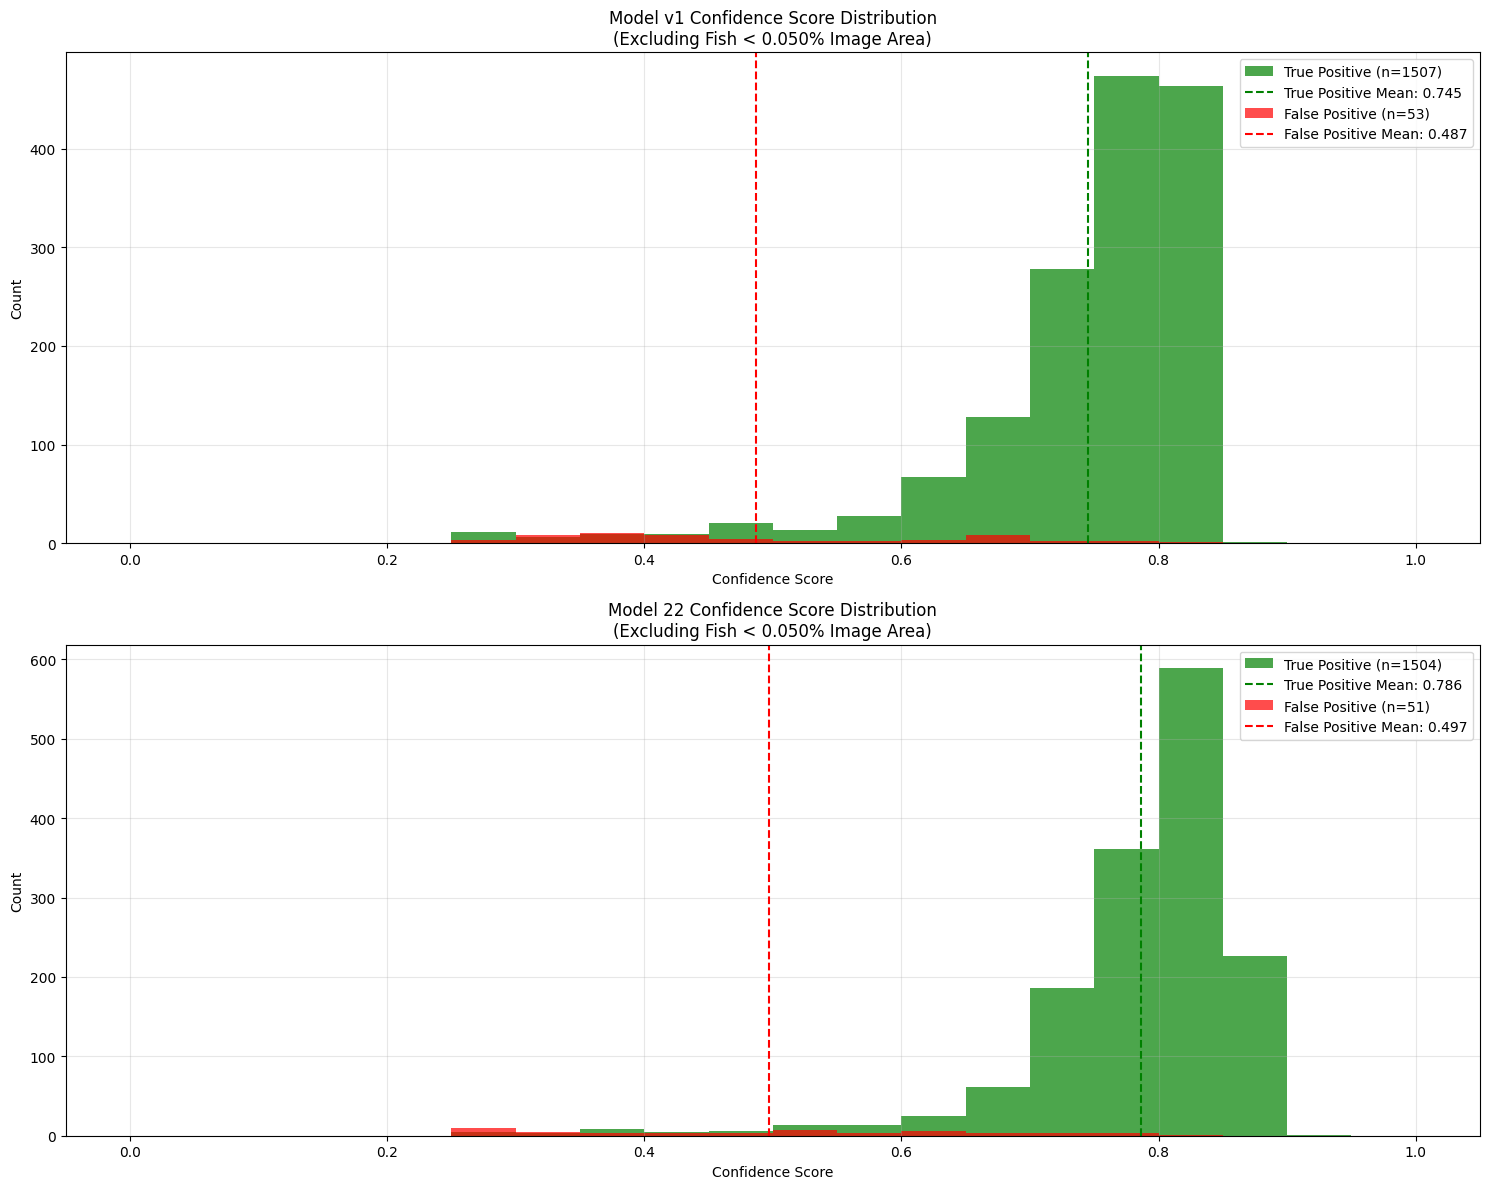

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Configuration object for easy adjustment
CONFIG = {
    'area_threshold': 0.0005,  # 0.05% of image area
    'conf_threshold': 0.25,    # Minimum confidence score
    'iou_threshold': 0.5,      # IoU threshold for true positives
    'experiments': [
        ("yolov8l_dataset_v5_v1", 1),
        ("yolov8l_dataset_v5_v22", 1)
    ]
}

def plot_confidence_histogram_by_size(config):
    """
    Plot confidence score histograms for both models, excluding tiny fish detections
    """
    base_path = './triggerfish_detection/detection_training_runs'
    plot_data = []
    
    for exp_id, res_num in config['experiments']:
        pred_path = Path(base_path) / exp_id / 'test_set_validation' / f'results{res_num}' / 'labels'
        gt_path = Path('./triggerfish_detection/dataset_v5/labels/test')
        
        tiny_fish_count = 0
        total_detections = 0
        
        try:
            for pred_file in pred_path.glob('*.txt'):
                img_name = pred_file.stem
                gt_file = gt_path / f'{img_name}.txt'
                
                # Read ground truth boxes
                gt_boxes = []
                if gt_file.exists():
                    with open(gt_file, 'r') as f:
                        for line in f:
                            parts = line.strip().split()
                            if len(parts) >= 5:
                                class_id, x_center, y_center, width, height = map(float, parts[:5])
                                gt_boxes.append({
                                    'x': x_center,
                                    'y': y_center,
                                    'width': width,
                                    'height': height
                                })
                
                # Read predictions
                with open(pred_file, 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 6:
                            class_id, x_center, y_center, width, height, conf = map(float, parts[:6])
                            total_detections += 1
                            
                            # Calculate normalized area
                            area = width * height
                            
                            # Count and skip tiny detections
                            if area < config['area_threshold']:
                                tiny_fish_count += 1
                                continue
                                
                            # Skip low confidence predictions
                            if conf < config['conf_threshold']:
                                continue
                            
                            pred_box = {
                                'x': x_center,
                                'y': y_center,
                                'width': width,
                                'height': height,
                                'confidence': conf,
                                'area': area
                            }
                            
                            # Check if it's a true positive
                            is_tp = False
                            best_iou = 0
                            for gt_box in gt_boxes:
                                iou = calculate_iou(pred_box, gt_box)
                                if iou > best_iou:
                                    best_iou = iou
                                if iou > config['iou_threshold']:
                                    is_tp = True
                                    break
                            
                            plot_data.append({
                                'Model': f'Model {exp_id[-2:]}',
                                'Category': 'True Positive' if is_tp else 'False Positive',
                                'Confidence': conf,
                                'Area': area,
                                'IoU': best_iou
                            })
            
            print(f"\nModel {exp_id}:")
            print(f"Total detections: {total_detections}")
            print(f"Tiny fish excluded (area < {config['area_threshold']:.6f}): {tiny_fish_count}")
            print(f"Percentage excluded: {(tiny_fish_count/total_detections*100):.1f}%")
            
        except Exception as e:
            print(f"Error processing {exp_id}: {e}")
            continue
    
    # Convert to DataFrame
    df = pd.DataFrame(plot_data)
    
    # Create figure
    fig, axes = plt.subplots(2, 1, figsize=(15, 12))
    
    # Plot settings
    bins = np.linspace(0, 1, 21)
    colors = {'True Positive': 'green', 'False Positive': 'red'}
    
    # Plot for each model
    for idx, model in enumerate(df['Model'].unique()):
        model_data = df[df['Model'] == model]
        ax = axes[idx]
        
        for category in ['True Positive', 'False Positive']:
            data = model_data[model_data['Category'] == category]['Confidence']
            ax.hist(data, bins=bins, color=colors[category], alpha=0.7, 
                   label=f'{category} (n={len(data)})')
            if len(data) > 0:
                mean_val = data.mean()
                ax.axvline(mean_val, color=colors[category], linestyle='--', 
                          label=f'{category} Mean: {mean_val:.3f}')
        
        ax.set_title(f'{model} Confidence Score Distribution\n(Excluding Fish < {config["area_threshold"]*100:.3f}% Image Area)')
        ax.set_xlabel('Confidence Score')
        ax.set_ylabel('Count')
        ax.grid(True, alpha=0.3)
        ax.legend()
        
        # Print statistics
        print(f"\n{model} Statistics (excluding tiny fish):")
        for category in ['True Positive', 'False Positive']:
            stats = model_data[model_data['Category'] == category]['Confidence'].describe()
            print(f"\n{category}:")
            print(f"Count: {stats['count']:.0f}")
            print(f"Mean: {stats['mean']:.3f}")
            print(f"Std: {stats['std']:.3f}")
            print(f"Min: {stats['min']:.3f}")
            print(f"Max: {stats['max']:.3f}")
            print(f"25%: {stats['25%']:.3f}")
            print(f"50%: {stats['50%']:.3f}")
            print(f"75%: {stats['75%']:.3f}")
    
    plt.tight_layout()
    
    # Save the plot
    save_dir = Path('./triggerfish_detection/detection_training_runs/confidence_analysis')
    save_dir.mkdir(exist_ok=True)
    save_path = save_dir / f'confidence_histogram_size_{CONFIG["area_threshold"]:.6f}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\nSaved plot to: {save_path}")
    
    plt.show()

if __name__ == "__main__":
    # Run with current configuration
    plot_confidence_histogram_by_size(CONFIG)

## 6. Conclusion

Model v22 has a higher mAP50, mAP50-95, recall, and F1 score than Model v1. However, the Precision is lower for Model v22. So Model v22 is better at detecting triggerfish than Model v1, but it is about 1% more likely to incorrectly label things as fish when they're not


Model v22 will likely do very well on our full dataset. It could be used as a single pass and then False Positive detections could be removed based on something like Kalman Filtering.

Alternatively, we could set the threshold to 0.5, which would give us a higher rate of True Positive detection, but at the cost of increased False Positives. We could then use a second pass with another model with a Higher Precision to remove the False Positives.

## 7. Train another model with a higher precision (Experiment v23)

In [ ]:
# Train the model with new parameters

import os
import torch
import wandb
from ultralytics import YOLO
from datetime import datetime
import time

# Record start time
start_time = time.time()
start_datetime = datetime.now()

print(f"Training started at: {start_datetime.strftime('%Y-%m-%d %H:%M:%S')}")


# Set PyTorch memory management
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# Define optimized training parameters for CPU
YOLO_MODEL = 'yolov8l'
EPOCHS = 100
PATIENCE = 20
BATCH_SIZE = 2 # Increased from 2
IMG_SIZE = 1280
LEARNING_RATE = 0.001 # Yolo default is 0.01. This architecture is very sensitive to the learning rate.
WORKERS = 4 # This speeds up the training process by preventing training being bottlenecked by data loading.
DEVICE=0
 
# Define directories
BASE_DIR = './triggerfish_detection'
EXPERIMENT_NUM=f"v23"
EXPERIMENT_ID = f"{YOLO_MODEL}_dataset_v5_{EXPERIMENT_NUM}"

PROJECT = "triggerfish_detection_runs"
DATASET_PATH = './triggerfish_detection/dataset_v5'
OUTPUT_DIR = os.path.join(PROJECT, EXPERIMENT_ID)


# Initialize wandb
wandb.init(
    project=PROJECT,
    name=EXPERIMENT_ID,
    config={
        "architecture": YOLO_MODEL,
        "dataset": "dataset_v5",
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "img_size": IMG_SIZE,
        "learning_rate": LEARNING_RATE,
        "patience": PATIENCE,
        "device": 'gpu',
        
    }
)
 
# Initialize model
model = YOLO(YOLO_MODEL + '.pt')
model.train(
    # data configuration
    data=DATASET_PATH+'/data.yaml',
    imgsz=IMG_SIZE,
    # training configuration
    epochs=EPOCHS,
    patience=PATIENCE,
    # batch configuration 
    batch=BATCH_SIZE,
    # learning rate configuration
    lr0=LEARNING_RATE,
    device=DEVICE,
    save=True,
    project='./triggerfish_detection/detection_training_runs',  # Base directory
    name=EXPERIMENT_ID,                                        # Experiment subfold
    workers=WORKERS,
    max_det=50,
    amp=True,           # Enable mixed precision training
    cache='disk',         # Cache images in RAM
    optimizer='AdamW'   # Memory efficient optimizer
    conf=0.25,
    iou=0.5,
)

wandb.finish()

print(f"\nTraining completed. Model saved in: {OUTPUT_DIR}")

# Calculate and display duration
end_time = time.time()
end_datetime = datetime.now()

duration_seconds = end_time - start_time
hours = int(duration_seconds // 3600)
minutes = int((duration_seconds % 3600) // 60)
seconds = int(duration_seconds % 60)

print(f"\nTraining completed at: {end_datetime.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total training time: {hours}h {minutes}m {seconds}s")
print(f"Total training time in seconds: {duration_seconds:.2f}s")